In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

In [2]:
#!/usr/bin/env python3
"""
Process LAGO RAW v5 file:
- parse events separated by '# t' lines
- compute baseline, peak, integrated charge per event (channel 1 by default)
- save per-event summary CSV and charges list
- plot sample pulses, average pulse, and histogram of charges

Usage:
    python process_lago_raw.py

Adjust parameters below as needed.
"""
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ---------------------------
# USER PARAMETERS
# ---------------------------
FILENAME = "pura_fondo.dat"               # <-- cambia por el nombre real
OUTDIR = "Analisis-pulsos-señales-Agua-pura-fondo"
FIGDIR = os.path.join(OUTDIR, "figs")
CHANNEL = 0                                # 0 -> primer número (ADC1), 1 -> segunda columna (ADC2)
N_BASELINE = 20                            # muestras iniciales usadas para baseline
INTEGRATE_POSITIVE_ONLY = True             # si True, integrar (sample - baseline) > 0 sólo
SAVE_SAMPLE_PULSES = 50                    # cuántos pulsos guardar como PNG ejemplo (si hay)
AVERAGE_WINDOW = 200                       # tamaño (en muestras) de la ventana para promedio centrado en peak
HIST_BINS = 6000
# ---------------------------

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)

def parse_events_stream(filename):
    """
    Generator that yields events. Each event is a list of (adc1,adc2) floats.
    Event is terminated whenever a line starting with '# t' is encountered.
    """
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                # event boundary: '# t' marks end of trigger block (in the file you showed)
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            # Try parse two numeric columns (some lines could be malformed)
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                except:
                    continue
                current.append((a, b))
            else:
                # not a valid data line, skip
                continue
        # end of file: flush last event
        if current:
            yield np.array(current, dtype=float)


def process_event_samples(samples, channel=0, n_baseline=20):
    """
    Procesa un evento y retorna:
      - n_samples
      - baseline
      - peak_val
      - peak_idx
      - charge
      - signal
      - start, end  (ventana usada)
    """
    ch = samples[:, channel]
    N = len(ch)
    if N == 0:
        return None

    # Baseline
    nb = min(n_baseline, N)
    baseline = np.mean(ch[:nb])
    signal = ch - baseline

    # Peak
    peak_idx = int(np.argmax(signal))
    peak_val = float(signal[peak_idx])

    # Ignorar eventos raros o negativos
    if peak_val <= 0:
        return None

    # Ventanas (5% del pico)
    threshold = 0.05 * peak_val

    # Buscar inicio
    start_idx = 0
    for i in range(peak_idx, -1, -1):
        if signal[i] < threshold:
            start_idx = i + 1
            break

    # Buscar final
    end_idx = N - 1
    for i in range(peak_idx, N):
        if signal[i] < threshold:
            end_idx = i
            break

    # Integración positiva
    window = signal[start_idx:end_idx]
    window = np.where(window > 0, window, 0.0)
    charge = float(np.sum(window))

    return {
        "n_samples": N,
        "baseline": float(baseline),
        "peak_val": peak_val,
        "peak_idx": peak_idx,
        "start": start_idx,
        "end": end_idx,
        "charge": charge,
        "signal": signal
    }

def save_summary_txt(records, outpath):
    with open(outpath, "w") as f:
        f.write("# Resumen de eventos – LAGO RAW v5\n")
        f.write("# Columnas:\n")
        f.write("# event_index  n_samples  baseline  peak_val  peak_idx  charge\n")
        f.write("# ------------------------------------------------------------\n")

        for r in records:
            line = (
                f"{r['event_index']:8d}  "
                f"{r['n_samples']:9d}  "
                f"{r['baseline']:10.3f}  "
                f"{r['peak_val']:10.3f}  "
                f"{r['peak_idx']:8d}  "
                f"{r['charge']:12.3f}\n"
            )
            f.write(line)


def plot_sample_pulses(records, figpath, max_plots=50):
    """Plot several raw pulses (signal after baseline subtraction)."""
    n = min(len(records), max_plots)
    plt.figure(figsize=(10,6))
    for i in range(n):
        sig = records[i]["signal"]
        plt.plot(sig, alpha=0.6, linewidth=0.8)
    plt.xlabel("Índice de la muestra", fontsize=16)
    plt.ylabel("Señal (ADC - lineabase)", fontsize=16)
    #plt.title(f"Sample pulses (first {n})")
    plt.grid(alpha=0.3)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.tight_layout()
    plt.savefig(figpath)
    plt.close()


def compute_average_pulse(records, window=200, figpath=None):
    """
    Align pulses on their peak and compute average waveform within a window.
    window = total number of samples to include (centered on peak when possible)
    """
    half = window // 2
    aligned = []
    for r in records:
        sig = r["signal"]
        p = r["peak_idx"]
        start = max(0, p - half)
        end = min(len(sig), p + half)
        seg = sig[start:end]
        # pad to length window with zeros if needed
        if len(seg) < window:
            seg = np.pad(seg, (0, window - len(seg)), constant_values=0)
        aligned.append(seg)
    if len(aligned) == 0:
        return None
    aligned = np.vstack(aligned)
    avg = np.mean(aligned, axis=0)
    std = np.std(aligned, axis=0)
    if figpath:
        x = np.arange(len(avg)) - half
        plt.figure(figsize=(8,5))
        plt.plot(x, avg, label="avg", lw=2)
        plt.fill_between(x, avg - std, avg + std, alpha=0.3, label="±1σ")
        plt.xlabel("Muestra relativa al pico", fontsize=16)
        plt.xlabel("Indice de la muestra", fontsize=16)
        plt.title("")
        #Average pulse aligned on peak
        plt.legend(fontsize=16)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(figpath)
        plt.close()
    return avg, std


def plot_charge_histogram(charges, figpath):

    # rango automático completo
    xmin = 0
    #xmax = np.max(charges) * 1.05   # 5% extra
    xmax = 40001

    plt.figure(figsize=(8,5))

    # número de bins MUCHO menor → verás el rango completo
    bins = 1000

    counts, edges = np.histogram(charges, bins=bins, range=(xmin, xmax))
    centers = 0.5 * (edges[:-1] + edges[1:])

    
    #plt.plot(centers, counts, lw=1.2)
    plt.plot(centers, counts, lw=1.2, color="grey")

    plt.yscale("log")
    #plt.xlabel("ADC [u.a]")
    #plt.ylabel("Cuentas [u.a.]")
    plt.xlabel("ADC [u.a]", fontsize=16)
    plt.xlim(0, 40001)
    #plt.ylim(1e-4, 2)
    plt.ylabel("Cuentas [u.a.]", fontsize=16)
    plt.title("", fontsize=16)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)


    plt.title("")

    plt.grid(alpha=0.3)
    #plt.xticks(np.arange(0, xmax, 10000))
    plt.xticks(np.arange(0, xmax, 10000), fontsize=16)
    #ax = plt.gca()
    #ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    #ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))


    plt.tight_layout()
    plt.savefig(figpath)
    plt.close()


def main():
    print("Processing file:", FILENAME)
    events_generator = parse_events_stream(FILENAME)

    records = []
    charges = []
    event_idx = 0
    sample_plots_saved = 0
    # We'll store first few records (with signal arrays) for plotting
    sample_records = []

    for samples in events_generator:
        event_idx += 1
    
        # llamada corregida:
        res = process_event_samples(samples, channel=CHANNEL, n_baseline=N_BASELINE)
    
        if res is None:
            continue

        res["event_index"] = event_idx
        records.append(res)
        charges.append(res["charge"])

        if len(sample_records) < SAVE_SAMPLE_PULSES:
            sample_records.append(res)

        if event_idx % 500 == 0:
            print(f"Processed {event_idx} events...")




    print(f"Total events processed: {event_idx}")
    # Save results
    charges = np.array(charges)
    np.savetxt(os.path.join(OUTDIR, "carga-fondo-Agua-pura.txt"), charges, fmt="%.6f")
    #save_summary_csv(records, os.path.join(OUTDIR, "Carga-resumen-25NaCl-fondo.csv"))
    save_summary_txt(records, os.path.join(OUTDIR, "Carga-resumen-Agua-pura-fondo.txt"))


    # Plot sample pulses
    if len(sample_records) > 0:
        plot_sample_pulses(sample_records, os.path.join(FIGDIR, "Muestra-pulsos-fondo-AP.png"), max_plots=SAVE_SAMPLE_PULSES)

    # Average pulse aligned
    avgres = compute_average_pulse(sample_records, window=AVERAGE_WINDOW, figpath=os.path.join(FIGDIR, "Pulso-promedio-AP.png"))
    if avgres is not None:
        print("Saved average pulse.")

    # Plot histogram of charges
    #plot_charge_histogram(charges, os.path.join(FIGDIR, "Histograma-carga-fondo-25NaCl.png"), bins=HIST_BINS)
    plot_charge_histogram(charges, os.path.join(FIGDIR, "Histograma-carga-fondo-AP-1.png"))

    print("Saved histogram and results to", OUTDIR)

if __name__ == "__main__":
    main()


Processing file: pura_fondo.dat
Processed 500 events...
Processed 1000 events...
Processed 1500 events...
Processed 2000 events...
Processed 2500 events...
Processed 3000 events...
Processed 3500 events...
Processed 4000 events...
Processed 4500 events...
Processed 5000 events...
Processed 5500 events...
Processed 6000 events...
Processed 6500 events...
Processed 7000 events...
Processed 7500 events...
Processed 8000 events...
Processed 8500 events...
Processed 9000 events...
Processed 9500 events...
Processed 10000 events...
Processed 10500 events...
Processed 11000 events...
Processed 11500 events...
Processed 12000 events...
Processed 12500 events...
Processed 13000 events...
Processed 13500 events...
Processed 14000 events...
Processed 14500 events...
Processed 15000 events...
Processed 15500 events...
Processed 16000 events...
Processed 16500 events...
Processed 17000 events...
Processed 17500 events...
Processed 18000 events...
Processed 18500 events...
Processed 19000 events...


In [3]:
#!/usr/bin/env python3
"""
Process LAGO RAW v5 file:
- parse events separated by '# t' lines
- compute baseline, peak, integrated charge per event (channel 1 by default)
- save per-event summary CSV and charges list
- plot sample pulses, average pulse, and histogram of charges

Usage:
    python process_lago_raw.py

Adjust parameters below as needed.
"""
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ---------------------------
# USER PARAMETERS
# ---------------------------
FILENAME = "2.5_fondo.dat"               # <-- cambia por el nombre real
OUTDIR = "Fondo-Agua-25NaCl"
FIGDIR = os.path.join(OUTDIR, "figs")
CHANNEL = 0                                # 0 -> primer número (ADC1), 1 -> segunda columna (ADC2)
N_BASELINE = 20                            # muestras iniciales usadas para baseline
INTEGRATE_POSITIVE_ONLY = True             # si True, integrar (sample - baseline) > 0 sólo
SAVE_SAMPLE_PULSES = 50                    # cuántos pulsos guardar como PNG ejemplo (si hay)
AVERAGE_WINDOW = 200                       # tamaño (en muestras) de la ventana para promedio centrado en peak
HIST_BINS = 6000
# ---------------------------

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)

def parse_events_stream(filename):
    """
    Generator that yields events. Each event is a list of (adc1,adc2) floats.
    Event is terminated whenever a line starting with '# t' is encountered.
    """
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                # event boundary: '# t' marks end of trigger block (in the file you showed)
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            # Try parse two numeric columns (some lines could be malformed)
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                except:
                    continue
                current.append((a, b))
            else:
                # not a valid data line, skip
                continue
        # end of file: flush last event
        if current:
            yield np.array(current, dtype=float)


def process_event_samples(samples, channel=0, n_baseline=20):
    """
    Procesa un evento y retorna:
      - n_samples
      - baseline
      - peak_val
      - peak_idx
      - charge
      - signal
      - start, end  (ventana usada)
    """
    ch = samples[:, channel]
    N = len(ch)
    if N == 0:
        return None

    # Baseline
    nb = min(n_baseline, N)
    baseline = np.mean(ch[:nb])
    signal = ch - baseline

    # Peak
    peak_idx = int(np.argmax(signal))
    peak_val = float(signal[peak_idx])

    # Ignorar eventos raros o negativos
    if peak_val <= 0:
        return None

    # Ventanas (5% del pico)
    threshold = 0.05 * peak_val

    # Buscar inicio
    start_idx = 0
    for i in range(peak_idx, -1, -1):
        if signal[i] < threshold:
            start_idx = i + 1
            break

    # Buscar final
    end_idx = N - 1
    for i in range(peak_idx, N):
        if signal[i] < threshold:
            end_idx = i
            break

    # Integración positiva
    window = signal[start_idx:end_idx]
    window = np.where(window > 0, window, 0.0)
    charge = float(np.sum(window))

    return {
        "n_samples": N,
        "baseline": float(baseline),
        "peak_val": peak_val,
        "peak_idx": peak_idx,
        "start": start_idx,
        "end": end_idx,
        "charge": charge,
        "signal": signal
    }


def save_summary_csv(records, outpath):
    import csv
    hdr = ["event_index", "n_samples", "baseline", "peak_val", "peak_idx", "charge"]
    with open(outpath, "w", newline='') as csvfile:
        writer = csv.writer(csvfile, delimiter=",")
        writer.writerow(hdr)
        for r in records:
            writer.writerow([r["event_index"], r["n_samples"], r["baseline"], r["peak_val"], r["peak_idx"], r["charge"]])


def plot_sample_pulses(records, figpath, max_plots=50):
    """Plot several raw pulses (signal after baseline subtraction)."""
    n = min(len(records), max_plots)
    plt.figure(figsize=(10,6))
    for i in range(n):
        sig = records[i]["signal"]
        plt.plot(sig, alpha=0.6, linewidth=0.8)
    plt.xlabel("Sample index")
    plt.ylabel("Signal (ADC - baseline)")
    plt.title(f"Sample pulses (first {n})")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(figpath)
    plt.close()


def compute_average_pulse(records, window=200, figpath=None):
    """
    Align pulses on their peak and compute average waveform within a window.
    window = total number of samples to include (centered on peak when possible)
    """
    half = window // 2
    aligned = []
    for r in records:
        sig = r["signal"]
        p = r["peak_idx"]
        start = max(0, p - half)
        end = min(len(sig), p + half)
        seg = sig[start:end]
        # pad to length window with zeros if needed
        if len(seg) < window:
            seg = np.pad(seg, (0, window - len(seg)), constant_values=0)
        aligned.append(seg)
    if len(aligned) == 0:
        return None
    aligned = np.vstack(aligned)
    avg = np.mean(aligned, axis=0)
    std = np.std(aligned, axis=0)
    if figpath:
        x = np.arange(len(avg)) - half
        plt.figure(figsize=(8,5))
        plt.plot(x, avg, label="avg", lw=2)
        plt.fill_between(x, avg - std, avg + std, alpha=0.3, label="±1σ")
        plt.xlabel("Samples relative to peak")
        plt.ylabel("Signal (ADC - baseline)")
        plt.title("Average pulse aligned on peak")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(figpath)
        plt.close()
    return avg, std


def plot_charge_histogram(charges, figpath):

    # rango automático completo
    xmin = 0
    #xmax = np.max(charges) * 1.05   # 5% extra
    xmax = 40001

    plt.figure(figsize=(8,5))

    # número de bins MUCHO menor → verás el rango completo
    bins = 1000

    counts, edges = np.histogram(charges, bins=bins, range=(xmin, xmax))
    centers = 0.5 * (edges[:-1] + edges[1:])

    
    #plt.plot(centers, counts, lw=1.2)
    plt.plot(centers, counts, lw=1.2, color="grey")

    plt.yscale("log")
    #plt.xlabel("ADC [u.a]")
    #plt.ylabel("Cuentas [u.a.]")
    plt.xlabel("ADC [u.a]", fontsize=16)
    plt.xlim(0, 40001)
    #plt.ylim(1e-4, 2)
    plt.ylabel("Cuentas [u.a.]", fontsize=16)
    plt.title("", fontsize=16)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)


    plt.title("")

    plt.grid(alpha=0.3)
    #plt.xticks(np.arange(0, xmax, 10000))
    plt.xticks(np.arange(0, xmax, 10000), fontsize=16)
    #ax = plt.gca()
    #ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    #ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))


    plt.tight_layout()
    plt.savefig(figpath)
    plt.close()


def main():
    print("Processing file:", FILENAME)
    events_generator = parse_events_stream(FILENAME)

    records = []
    charges = []
    event_idx = 0
    sample_plots_saved = 0
    # We'll store first few records (with signal arrays) for plotting
    sample_records = []

    for samples in events_generator:
        event_idx += 1
    
        # llamada corregida:
        res = process_event_samples(samples, channel=CHANNEL, n_baseline=N_BASELINE)
    
        if res is None:
            continue

        res["event_index"] = event_idx
        records.append(res)
        charges.append(res["charge"])

        if len(sample_records) < SAVE_SAMPLE_PULSES:
            sample_records.append(res)

        if event_idx % 500 == 0:
            print(f"Processed {event_idx} events...")




    print(f"Total events processed: {event_idx}")
    # Save results
    charges = np.array(charges)
    np.savetxt(os.path.join(OUTDIR, "carga-fondo-25NaCl.txt"), charges, fmt="%.6f")
    save_summary_csv(records, os.path.join(OUTDIR, "Carga-resumen-25NaCl-fondo.csv"))

    # Plot sample pulses
    if len(sample_records) > 0:
        plot_sample_pulses(sample_records, os.path.join(FIGDIR, "Muestra-pulsos-fondo-25NaCl.png"), max_plots=SAVE_SAMPLE_PULSES)

    # Average pulse aligned
    avgres = compute_average_pulse(sample_records, window=AVERAGE_WINDOW, figpath=os.path.join(FIGDIR, "Pulso-promedio-25NaCl.png"))
    if avgres is not None:
        print("Saved average pulse.")

    # Plot histogram of charges
    #plot_charge_histogram(charges, os.path.join(FIGDIR, "Histograma-carga-fondo-25NaCl.png"), bins=HIST_BINS)
    plot_charge_histogram(charges, os.path.join(FIGDIR, "Histograma-carga-fondo-25NaCl-1.png"))

    print("Saved histogram and results to", OUTDIR)

if __name__ == "__main__":
    main()


Processing file: 2.5_fondo.dat
Processed 500 events...
Processed 1000 events...
Processed 1500 events...
Processed 2000 events...
Processed 2500 events...
Processed 3000 events...
Processed 3500 events...
Processed 4000 events...
Processed 4500 events...
Processed 5000 events...
Processed 5500 events...
Processed 6000 events...
Processed 6500 events...
Processed 7000 events...
Processed 7500 events...
Processed 8000 events...
Processed 8500 events...
Processed 9000 events...
Processed 9500 events...
Processed 10000 events...
Processed 10500 events...
Processed 11000 events...
Processed 11500 events...
Processed 12000 events...
Processed 12500 events...
Processed 13000 events...
Processed 13500 events...
Processed 14000 events...
Processed 14500 events...
Processed 15000 events...
Processed 15500 events...
Processed 16000 events...
Processed 16500 events...
Processed 17000 events...
Processed 17500 events...
Processed 18000 events...
Processed 18500 events...
Processed 19000 events...
P

In [4]:
#!/usr/bin/env python3
"""
Process LAGO RAW v5 file:
- parse events separated by '# t' lines
- compute baseline, peak, integrated charge per event (channel 1 by default)
- save per-event summary CSV and charges list
- plot sample pulses, average pulse, and histogram of charges

Usage:
    python process_lago_raw.py

Adjust parameters below as needed.
"""
import os
import numpy as np
#import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from collections import deque

# ---------------------------
# USER PARAMETERS
# ---------------------------
FILENAME = "2.5_neutrones.dat"               # <-- cambia por el nombre real
OUTDIR = "ADC-Agua-25NaCl"
FIGDIR = os.path.join(OUTDIR, "figs")
CHANNEL = 0                                # 0 -> primer número (ADC1), 1 -> segunda columna (ADC2)
N_BASELINE = 20                            # muestras iniciales usadas para baseline
INTEGRATE_POSITIVE_ONLY = True             # si True, integrar (sample - baseline) > 0 sólo
SAVE_SAMPLE_PULSES = 50                    # cuántos pulsos guardar como PNG ejemplo (si hay)
AVERAGE_WINDOW = 200                       # tamaño (en muestras) de la ventana para promedio centrado en peak
HIST_BINS = 6000
# ---------------------------

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)

def parse_events_stream(filename):
    """
    Generator that yields events. Each event is a list of (adc1,adc2) floats.
    Event is terminated whenever a line starting with '# t' is encountered.
    """
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                # event boundary: '# t' marks end of trigger block (in the file you showed)
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            # Try parse two numeric columns (some lines could be malformed)
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                except:
                    continue
                current.append((a, b))
            else:
                # not a valid data line, skip
                continue
        # end of file: flush last event
        if current:
            yield np.array(current, dtype=float)


def process_event_samples(samples, channel=0, n_baseline=20):
    """
    Procesa un evento y retorna:
      - n_samples
      - baseline
      - peak_val
      - peak_idx
      - charge
      - signal
      - start, end  (ventana usada)
    """
    ch = samples[:, channel]
    N = len(ch)
    if N == 0:
        return None

    # Baseline
    nb = min(n_baseline, N)
    baseline = np.mean(ch[:nb])
    signal = ch - baseline

    # Peak
    peak_idx = int(np.argmax(signal))
    peak_val = float(signal[peak_idx])

    # Ignorar eventos raros o negativos
    if peak_val <= 0:
        return None

    # Ventanas (5% del pico)
    threshold = 0.05 * peak_val

    # Buscar inicio
    start_idx = 0
    for i in range(peak_idx, -1, -1):
        if signal[i] < threshold:
            start_idx = i + 1
            break

    # Buscar final
    end_idx = N - 1
    for i in range(peak_idx, N):
        if signal[i] < threshold:
            end_idx = i
            break

    # Integración positiva
    window = signal[start_idx:end_idx]
    window = np.where(window > 0, window, 0.0)
    charge = float(np.sum(window))

    return {
        "n_samples": N,
        "baseline": float(baseline),
        "peak_val": peak_val,
        "peak_idx": peak_idx,
        "start": start_idx,
        "end": end_idx,
        "charge": charge,
        "signal": signal
    }


def save_summary_csv(records, outpath):
    import csv
    hdr = ["event_index", "n_samples", "baseline", "peak_val", "peak_idx", "charge"]
    with open(outpath, "w", newline='') as csvfile:
        writer = csv.writer(csvfile, delimiter=",")
        writer.writerow(hdr)
        for r in records:
            writer.writerow([r["event_index"], r["n_samples"], r["baseline"], r["peak_val"], r["peak_idx"], r["charge"]])


def plot_sample_pulses(records, figpath, max_plots=50):
    """Plot several raw pulses (signal after baseline subtraction)."""
    n = min(len(records), max_plots)
    plt.figure(figsize=(10,6))
    for i in range(n):
        sig = records[i]["signal"]
        plt.plot(sig, alpha=0.6, linewidth=0.8)
    plt.xlabel("Sample index")
    plt.ylabel("Signal (ADC - baseline)")
    plt.title(f"Sample pulses (first {n})")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(figpath)
    plt.close()


def compute_average_pulse(records, window=200, figpath=None):
    """
    Align pulses on their peak and compute average waveform within a window.
    window = total number of samples to include (centered on peak when possible)
    """
    half = window // 2
    aligned = []
    for r in records:
        sig = r["signal"]
        p = r["peak_idx"]
        start = max(0, p - half)
        end = min(len(sig), p + half)
        seg = sig[start:end]
        # pad to length window with zeros if needed
        if len(seg) < window:
            seg = np.pad(seg, (0, window - len(seg)), constant_values=0)
        aligned.append(seg)
    if len(aligned) == 0:
        return None
    aligned = np.vstack(aligned)
    avg = np.mean(aligned, axis=0)
    std = np.std(aligned, axis=0)
    if figpath:
        x = np.arange(len(avg)) - half
        plt.figure(figsize=(8,5))
        plt.plot(x, avg, label="avg", lw=2)
        plt.fill_between(x, avg - std, avg + std, alpha=0.3, label="±1σ")
        plt.xlabel("Samples relative to peak")
        plt.ylabel("Signal (ADC - baseline)")
        plt.title("Average pulse aligned on peak")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(figpath)
        plt.close()
    return avg, std


def plot_charge_histogram(charges, figpath):

    # rango automático completo
    xmin = 0
    #xmax = np.max(charges) * 1.05   # 5% extra
    xmax = 40001

    plt.figure(figsize=(8,5))

    # número de bins MUCHO menor → verás el rango completo
    bins = 1000

    counts, edges = np.histogram(charges, bins=bins, range=(xmin, xmax))
    centers = 0.5 * (edges[:-1] + edges[1:])

    #plt.plot(centers, counts, lw=1.2)
    plt.plot(centers, counts, lw=1.2, color="green")


    plt.yscale("log")
    #plt.xlabel("ADC [u.a]")
    #plt.ylabel("Cuentas [u.a.]")
    plt.xlabel("ADC [u.a]", fontsize=16)
    plt.xlim(0, 40001)
    #plt.ylim(1e-4, 2)
    plt.ylabel("Cuentas [u.a.]", fontsize=16)
    plt.title("", fontsize=16)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)


    plt.title("")

    plt.grid(alpha=0.3)
    #plt.xticks(np.arange(0, xmax, 10000))
    plt.xticks(np.arange(0, xmax, 10000), fontsize=16)
    #ax = plt.gca()
    #ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    #ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

    plt.tight_layout()
    plt.savefig(figpath)
    plt.close()


def main():
    print("Processing file:", FILENAME)
    events_generator = parse_events_stream(FILENAME)

    records = []
    charges = []
    event_idx = 0
    sample_plots_saved = 0
    # We'll store first few records (with signal arrays) for plotting
    sample_records = []

    for samples in events_generator:
        event_idx += 1
    
        # llamada corregida:
        res = process_event_samples(samples, channel=CHANNEL, n_baseline=N_BASELINE)
    
        if res is None:
            continue

        res["event_index"] = event_idx
        records.append(res)
        charges.append(res["charge"])

        if len(sample_records) < SAVE_SAMPLE_PULSES:
            sample_records.append(res)

        if event_idx % 500 == 0:
            print(f"Processed {event_idx} events...")




    print(f"Total events processed: {event_idx}")
    # Save results
    charges = np.array(charges)
    np.savetxt(os.path.join(OUTDIR, "carga-Agua-25NaCl.txt"), charges, fmt="%.6f")
    save_summary_csv(records, os.path.join(OUTDIR, "Carga-resumen-25NaCl-fondo.csv"))

    # Plot sample pulses
    if len(sample_records) > 0:
        plot_sample_pulses(sample_records, os.path.join(FIGDIR, "Muestra-pulsos-Agua-25NaCl.png"), max_plots=SAVE_SAMPLE_PULSES)

    # Average pulse aligned
    avgres = compute_average_pulse(sample_records, window=AVERAGE_WINDOW, figpath=os.path.join(FIGDIR, "Pulso-promedio-Agua-25NaCl.png"))
    if avgres is not None:
        print("Saved average pulse.")

    # Plot histogram of charges
    #plot_charge_histogram(charges, os.path.join(FIGDIR, "Histograma-carga-fondo-25NaCl.png"), bins=HIST_BINS)
    plot_charge_histogram(charges, os.path.join(FIGDIR, "Histograma-carga-Agua-25NaCl-1.png"))

    
    print("Saved histogram and results to", OUTDIR)

if __name__ == "__main__":
    main()


Processing file: 2.5_neutrones.dat
Processed 500 events...
Processed 1000 events...
Processed 1500 events...
Processed 2000 events...
Processed 2500 events...
Processed 3000 events...
Processed 3500 events...
Processed 4000 events...
Processed 4500 events...
Processed 5000 events...
Processed 5500 events...
Processed 6000 events...
Processed 6500 events...
Processed 7000 events...
Processed 7500 events...
Processed 8000 events...
Processed 8500 events...
Processed 9000 events...
Processed 9500 events...
Processed 10000 events...
Processed 10500 events...
Processed 11000 events...
Processed 11500 events...
Processed 12000 events...
Processed 12500 events...
Processed 13000 events...
Processed 13500 events...
Processed 14000 events...
Processed 14500 events...
Processed 15000 events...
Processed 15500 events...
Processed 16000 events...
Processed 16500 events...
Processed 17000 events...
Processed 17500 events...
Processed 18000 events...
Processed 18500 events...
Processed 19000 events.

In [5]:
#!/usr/bin/env python3
"""
Process LAGO RAW v5 file:
- parse events separated by '# t' lines
- compute baseline, peak, integrated charge per event (channel 1 by default)
- save per-event summary CSV and charges list
- plot sample pulses, average pulse, and histogram of charges
"""

import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# USER PARAMETERS
# ---------------------------
FILENAME = "2.5_fondo.dat"
OUTDIR = "Fondo-Agua-25NaCl"
FIGDIR = os.path.join(OUTDIR, "figs")
CHANNEL = 0
N_BASELINE = 20
SAVE_SAMPLE_PULSES = 50
AVERAGE_WINDOW = 200
HIST_BINS = 3000

# Nueva ventana fija alrededor del peak
HALF_WINDOW = 20   # integra 40 muestras centradas en el pico
# ---------------------------

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)


def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue

            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                    current.append((a, b))
                except:
                    continue

        if current:
            yield np.array(current, dtype=float)


def process_event_samples(samples, channel=0, n_baseline=20):
    ch = samples[:, channel]
    N = len(ch)
    if N == 0:
        return None

    # Baseline
    nb = min(n_baseline, N)
    baseline = np.mean(ch[:nb])
    signal = ch - baseline

    # Peak
    peak_idx = int(np.argmax(signal))
    peak_val = float(signal[peak_idx])

    if peak_val <= 0:
        return None

    # --- NUEVA INTEGRACIÓN: ventana fija centrada en el pico ---
    start_idx = max(0, peak_idx - HALF_WINDOW)
    end_idx = min(N, peak_idx + HALF_WINDOW)

    window = signal[start_idx:end_idx]
    window = np.where(window > 0, window, 0.0)
    charge = float(np.sum(window))

    return {
        "n_samples": N,
        "baseline": float(baseline),
        "peak_val": peak_val,
        "peak_idx": peak_idx,
        "start": start_idx,
        "end": end_idx,
        "charge": charge,
        "signal": signal
    }


def save_summary_csv(records, outpath):
    import csv
    hdr = ["event_index", "n_samples", "baseline", "peak_val", "peak_idx", "charge"]
    with open(outpath, "w", newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(hdr)
        for r in records:
            writer.writerow([r["event_index"], r["n_samples"], r["baseline"], r["peak_val"], r["peak_idx"], r["charge"]])


def plot_sample_pulses(records, figpath, max_plots=50):
    n = min(len(records), max_plots)
    plt.figure(figsize=(10,6))
    for i in range(n):
        sig = records[i]["signal"]
        plt.plot(sig, alpha=0.6, linewidth=0.8)

    plt.xlabel("Sample index")
    plt.ylabel("Signal (ADC - baseline)")
    plt.title(f"Sample pulses (first {n})")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(figpath)
    plt.close()


def compute_average_pulse(records, window=200, figpath=None):
    half = window // 2
    aligned = []

    for r in records:
        sig = r["signal"]
        p = r["peak_idx"]
        start = max(0, p - half)
        end = min(len(sig), p + half)
        seg = sig[start:end]
        if len(seg) < window:
            seg = np.pad(seg, (0, window - len(seg)), constant_values=0)
        aligned.append(seg)

    if len(aligned) == 0:
        return None

    aligned = np.vstack(aligned)
    avg = np.mean(aligned, axis=0)
    std = np.std(aligned, axis=0)

    if figpath:
        x = np.arange(len(avg)) - half
        plt.figure(figsize=(8,5))
        plt.plot(x, avg, label="avg", lw=2)
        plt.fill_between(x, avg - std, avg + std, alpha=0.3)
        plt.xlabel("Samples relative to peak")
        plt.ylabel("Signal (ADC - baseline)")
        plt.title("Average pulse aligned on peak")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(figpath)
        plt.close()

    return avg, std


def plot_charge_histogram(charges, figpath):

    xmin = 0
    xmax = np.max(charges) * 1.05

    plt.figure(figsize=(8,5))
    counts, edges = np.histogram(charges, bins=HIST_BINS, range=(xmin, xmax))
    centers = 0.5 * (edges[:-1] + edges[1:])

    plt.plot(centers, counts, lw=1.2)
    plt.yscale("log")
    plt.xlabel("ADC [u.a]")
    plt.ylabel("Cuentas [u.a.]")
    plt.title("Histogram of integrated charges")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(figpath)
    plt.close()


def main():
    print("Processing file:", FILENAME)

    events_generator = parse_events_stream(FILENAME)

    records = []
    sample_records = []
    charges = []
    event_idx = 0

    for samples in events_generator:
        event_idx += 1

        res = process_event_samples(samples, channel=CHANNEL, n_baseline=N_BASELINE)
        if res is None:
            continue

        res["event_index"] = event_idx
        records.append(res)
        charges.append(res["charge"])

        if len(sample_records) < SAVE_SAMPLE_PULSES:
            sample_records.append(res)

        if event_idx % 500 == 0:
            print(f"Processed {event_idx} events...")

    print(f"Total events processed: {event_idx}")

    charges = np.array(charges)
    np.savetxt(os.path.join(OUTDIR, "carga-fondo-25NaCl.txt"), charges, fmt="%.6f")
    save_summary_csv(records, os.path.join(OUTDIR, "Carga-resumen-25NaCl-fondo.csv"))

    if len(sample_records) > 0:
        plot_sample_pulses(sample_records, os.path.join(FIGDIR, "Muestra-pulsos-fondo-25NaCl.png"))

    compute_average_pulse(sample_records, window=AVERAGE_WINDOW, figpath=os.path.join(FIGDIR, "Pulso-promedio-25NaCl.png"))

    plot_charge_histogram(charges, os.path.join(FIGDIR, "Histograma-carga-fondo-25NaCl.png"))

    print("Saved histogram and results to", OUTDIR)


if __name__ == "__main__":
    main()


Processing file: 2.5_fondo.dat
Processed 500 events...
Processed 1000 events...
Processed 1500 events...
Processed 2000 events...
Processed 2500 events...
Processed 3000 events...
Processed 3500 events...
Processed 4000 events...
Processed 4500 events...
Processed 5000 events...
Processed 5500 events...
Processed 6000 events...
Processed 6500 events...
Processed 7000 events...
Processed 7500 events...
Processed 8000 events...
Processed 8500 events...
Processed 9000 events...
Processed 9500 events...
Processed 10000 events...
Processed 10500 events...
Processed 11000 events...
Processed 11500 events...
Processed 12000 events...
Processed 12500 events...
Processed 13000 events...
Processed 13500 events...
Processed 14000 events...
Processed 14500 events...
Processed 15000 events...
Processed 15500 events...
Processed 16000 events...
Processed 16500 events...
Processed 17000 events...
Processed 17500 events...
Processed 18000 events...
Processed 18500 events...
Processed 19000 events...
P

In [6]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


# ============================================================
# CONFIGURACIÓN DE ARCHIVOS
# ============================================================

FILES = {
    "Fondo": {
        "filename": "2.5_fondo.dat",
        "color": "blue",
        "label": "Espectro sin fuente de neutrones (agua + 2.5 % de NaCl)"
    },
    "Neutrones": {
        "filename": "2.5_neutrones.dat",
        "color": "green",
        "label": "Espectro de fuente de neutrones más el fondo (agua + 2.5 % de NaCl)"
    }
}

OUTDIR = "Comparacion-25NaCl"
FIGDIR = os.path.join(OUTDIR, "figs")
CHANNEL = 0
N_BASELINE = 20

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(FIGDIR, exist_ok=True)


# ============================================================
# PARSEADOR DE EVENTOS RAW
# ============================================================

def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                    current.append((a, b))
                except:
                    continue
        if current:
            yield np.array(current, dtype=float)


# ============================================================
# PROCESAMIENTO DE CADA EVENTO
# ============================================================

def process_event_samples(samples, channel=0, n_baseline=20):
    ch = samples[:, channel]
    N = len(ch)
    if N == 0:
        return None

    baseline = np.mean(ch[:min(n_baseline, N)])
    signal = ch - baseline

    peak_idx = int(np.argmax(signal))
    peak_val = float(signal[peak_idx])
    if peak_val <= 0:
        return None

    threshold = 0.05 * peak_val

    start = 0
    for i in range(peak_idx, -1, -1):
        if signal[i] < threshold:
            start = i + 1
            break

    end = N - 1
    for i in range(peak_idx, N):
        if signal[i] < threshold:
            end = i
            break

    window = signal[start:end]
    window = np.where(window > 0, window, 0.0)
    charge = float(np.sum(window))

    return charge


# ============================================================
# EXTRAER CARGAS DESDE ARCHIVO
# ============================================================

def extract_charges(filename):
    charges = []
    for event in parse_events_stream(filename):
        res = process_event_samples(event, channel=CHANNEL, n_baseline=N_BASELINE)
        if res is not None:
            charges.append(res)
    return np.array(charges)


# ============================================================
# GRAFICAR DOS CURVAS EN UNA SOLA FIGURA
# ============================================================

def plot_two_histograms(curves, figpath):

    plt.figure(figsize=(9,6))

    xmin = 0
    xmax = 40001
    bins = 1000

    for label, curve in curves.items():
        data = curve["charges"]
        color = curve["color"]
        legend = curve["label"]

        counts, edges = np.histogram(data, bins=bins, range=(xmin, xmax))
        centers = 0.5 * (edges[:-1] + edges[1:])

        plt.plot(centers, counts, lw=1.4, color=color, label=legend)

    plt.yscale("log")
    plt.xlabel("ADC [u.a.]", fontsize=16)
    plt.ylabel("Cuentas [u.a.]", fontsize=16)
    plt.ylim(1, 300000)
    plt.xticks(np.arange(0, xmax, 10000), fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig(figpath)
    plt.close()


# ============================================================
# PROGRAMA PRINCIPAL
# ============================================================

def main():

    curves = {}

    for key, info in FILES.items():
        print(f"Procesando: {info['filename']}")
        charges = extract_charges(info["filename"])
        curves[key] = {
            "charges": charges,
            "color": info["color"],
            "label": info["label"]
        }
        np.savetxt(os.path.join(OUTDIR, f"cargas-{key}.txt"), charges)

    print("Generando gráfica comparativa...")

    plot_two_histograms(
        curves,
        os.path.join(FIGDIR, "Comparacion-Histograma-ADC.png")
    )

    print("\nListo. Resultados guardados en:", OUTDIR)


if __name__ == "__main__":
    main()


Procesando: 2.5_fondo.dat
Procesando: 2.5_neutrones.dat
Generando gráfica comparativa...

Listo. Resultados guardados en: Comparacion-25NaCl


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "2.5_fondo.dat"
NEUTRONES_FILE = "2.5_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones"

CHANNEL = 0
BINS = 800
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0]); b = float(parts[1])
                    current.append((a, b))
                except:
                    continue
        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []
    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]
        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])
        signal = ch - baseline
        pos = signal.copy()
        pos[pos < 0] = 0.0
        q = pos.sum()
        charges.append(q)
    return np.array(charges)

# -------------------------------------
# PROCESAR AMBOS ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Neutrones:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMA COMPARADO
# -------------------------------------
plt.figure(figsize=(9,5))

maxrange = max(charges_fondo.max(), charges_neutrones.max()) * 1.1

#counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(0, maxrange))
#counts_neut, edges_neut = np.histogram(charges_neutrones, bins=BINS, range=(0, maxrange))

counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(100, 60000))
counts_neut, edges_neut = np.histogram(charges_neutrones, bins=BINS, range=(100, 60000))


centers_fondo = 0.5*(edges_fondo[:-1] + edges_fondo[1:])
centers_neut = 0.5*(edges_neut[:-1] + edges_neut[1:])

plt.plot(centers_fondo, counts_fondo, lw=1.5, label="Espectro sin fuente de neutrones (agua + 2.5 % de NaCl)", color="blue")
plt.plot(centers_neut, counts_neut, lw=1.5, label="Espectro de fuente de neutrones más el fondo (agua + 2.5 % de NaCl)", color="green")


plt.yscale("log")
plt.xlabel("ADC [u.a.]", fontsize=15)
plt.ylabel("Cuentas [u.a.]", fontsize=15)
plt.ylim(1, 300000)
plt.xlim(100, 56000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title("", fontsize=16)
plt.grid(alpha=0.3)
plt.legend(fontsize=10)

outname = os.path.join(OUTDIR, "Histograma-Comparado-Agua-25NaCl.png")
plt.savefig(outname, dpi=200)
plt.close()

print(f"\nGráfica guardada en: {outname}")


Eventos cargados:
 Fondo: 114227
 Neutrones: 1099688

Gráfica guardada en: Comparacion-robusta-fondo-neutrones/Histograma-Comparado-Agua-25NaCl.png


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "pura_fondo.dat"
NEUTRONES_FILE = "pura_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-agua-pura"

CHANNEL = 0
BINS = 800
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0]); b = float(parts[1])
                    current.append((a, b))
                except:
                    continue
        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []
    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]
        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])
        signal = ch - baseline
        pos = signal.copy()
        pos[pos < 0] = 0.0
        q = pos.sum()
        charges.append(q)
    return np.array(charges)

# -------------------------------------
# PROCESAR AMBOS ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Neutrones:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMA COMPARADO
# -------------------------------------
plt.figure(figsize=(9,6))

maxrange = max(charges_fondo.max(), charges_neutrones.max()) * 1.1

#counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(0, maxrange))
#counts_neut, edges_neut = np.histogram(charges_neutrones, bins=BINS, range=(0, maxrange))

counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(10, 60000))
counts_neut, edges_neut = np.histogram(charges_neutrones, bins=BINS, range=(10, 60000))


centers_fondo = 0.5*(edges_fondo[:-1] + edges_fondo[1:])
centers_neut = 0.5*(edges_neut[:-1] + edges_neut[1:])

plt.plot(centers_fondo, counts_fondo, lw=1.5, label="Espectro sin fuente de neutrones (agua pura)", color="blue")
plt.plot(centers_neut, counts_neut, lw=1.5, label="Espectro de fuente de neutrones más el fondo (agua pura)", color="red")


plt.yscale("log")
plt.xlabel("ADC [u.a.]", fontsize=20)
plt.ylabel("Cuentas [u.a.]", fontsize=20)
plt.ylim(1, 300000)
plt.xlim(100, 56000)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.title("", fontsize=16)
plt.grid(alpha=0.3)
plt.legend(fontsize=15)

outname = os.path.join(OUTDIR, "Histograma-Comparado-Agua-pura-original-1.png")
plt.savefig(outname, dpi=200)
plt.close()

print(f"\nGráfica guardada en: {outname}")


Eventos cargados:
 Fondo: 125401
 Neutrones: 563961

Gráfica guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Comparado-Agua-pura-original-1.png


In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "pura_fondo.dat"
NEUTRONES_FILE = "pura_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-agua-pura"

CHANNEL = 0
BINS = 800
RANGE_ADC = (10, 60000)

os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue

            if line.startswith("#"):
                if line.startswith("# t") and current:
                    yield np.array(current, dtype=float)
                    current = []
                continue

            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                    current.append((a, b))
                except ValueError:
                    continue

        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []

    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]

        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])

        signal = ch - baseline
        signal[signal < 0] = 0.0

        q = signal.sum()
        charges.append(q)

    return np.array(charges)

# -------------------------------------
# PROCESAR ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Fuente + fondo:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMAS
# -------------------------------------
counts_fondo, edges = np.histogram(
    charges_fondo,
    bins=BINS,
    range=RANGE_ADC
)

counts_neut, _ = np.histogram(
    charges_neutrones,
    bins=BINS,
    range=RANGE_ADC
)

centers = 0.5 * (edges[:-1] + edges[1:])

# Evitar problemas en escala logarítmica
counts_fondo_plot = np.where(counts_fondo > 0, counts_fondo, np.nan)
counts_neut_plot = np.where(counts_neut > 0, counts_neut, np.nan)

# -------------------------------------
# FIGURA PRINCIPAL
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=2.0,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua pura)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=2.0,
    color="red",
    label=r"Fuente $^{241}$AmBe + fondo (agua pura)"
)

ax.set_yscale("log")
ax.set_xlim(100, 56000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=30)
ax.set_ylabel("Número de cuentas por bin", fontsize=30)

ax.tick_params(axis="both", which="major", labelsize=28)
ax.tick_params(axis="both", which="minor", labelsize=28)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=28,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

# Nombre del archivo PNG
outname_png = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-pura-mejorado.png"
)

# Nombre del archivo PDF
outname_pdf = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-pura-mejorado.pdf"
)

# Guardar PNG
fig.savefig(
    outname_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

# Guardar PDF (vectorial)
fig.savefig(
    outname_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03
)

plt.close(fig)

print(f"\nGráfica PNG guardada en: {outname_png}")
print(f"Gráfica PDF guardada en: {outname_pdf}")


# -------------------------------------
# FIGURA CON ZOOM EN BAJAS CARGAS
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=2.0,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua pura)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=2.0,
    color="red",
    label=r"Fuente $^{241}$AmBe + fondo (agua pura)"
)

ax.set_yscale("log")
ax.set_xlim(100, 20000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Número de cuentas por bin", fontsize=22)

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_zoom = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-pura-zoom-bajas-cargas.png"
)

fig.savefig(
    outname_zoom,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

plt.close(fig)

print(f"Gráfica con zoom guardada en: {outname_zoom}")

Eventos cargados:
 Fondo: 125401
 Fuente + fondo: 563961

Gráfica PNG guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Comparado-Agua-pura-mejorado.png
Gráfica PDF guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Comparado-Agua-pura-mejorado.pdf
Gráfica con zoom guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Comparado-Agua-pura-zoom-bajas-cargas.png


In [31]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "pura_fondo.dat"
NEUTRONES_FILE = "pura_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-agua-pura"

CHANNEL = 0
BINS = 800
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0]); b = float(parts[1])
                    current.append((a, b))
                except:
                    continue
        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []
    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]
        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])
        signal = ch - baseline
        pos = signal.copy()
        pos[pos < 0] = 0.0
        q = pos.sum()
        charges.append(q)
    return np.array(charges)

# -------------------------------------
# PROCESAR AMBOS ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Neutrones:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMA COMPARADO
# -------------------------------------
plt.figure(figsize=(9,5))

# Rango fijo
MIN_X = 10
MAX_X = 60000

counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(MIN_X, MAX_X))
counts_neut, edges_neut = np.histogram(charges_neutrones, bins=BINS, range=(MIN_X, MAX_X))

centers = 0.5 * (edges_fondo[:-1] + edges_fondo[1:])

plt.plot(centers, counts_fondo, lw=1.5,
         label="Espectro sin fuente de neutrones (agua pura)",
         color="blue")

plt.plot(centers, counts_neut, lw=1.5,
         label="Espectro de fuente de neutrones más el fondo (agua pura)",
         color="red")

plt.yscale("log")
plt.xlabel("ADC [u.a.]", fontsize=15)
plt.ylabel("Cuentas [u.a.]", fontsize=15)
plt.ylim(1, 300000)
plt.xlim(100, 56000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=10)

outname = os.path.join(OUTDIR, "Histograma-Comparado-Agua-pura-1.png")
plt.savefig(outname, dpi=200)
plt.close()

print(f"\nGráfica guardada en: {outname}")

# -------------------------------------
# NUEVO: DIFERENCIA DE HISTOGRAMAS (bin a bin)
# -------------------------------------

diff = counts_neut - counts_fondo   # resta bin a bin

plt.figure(figsize=(9,5))
plt.plot(centers, diff, lw=1.4, color="black")

plt.axhline(0, color='red', lw=1)  # línea horizontal
plt.xlabel("ADC [u.a.]", fontsize=15)
plt.ylabel("Cuentas [u.a.]", fontsize=15)
plt.title("", fontsize=16)
plt.grid(alpha=0.3)
plt.xlim(100, 56000)

outname_diff = os.path.join(OUTDIR, "Histograma-Diferencia-Agua-pura.png")
plt.savefig(outname_diff, dpi=200)
plt.close()

print(f"Gráfica de diferencia guardada en: {outname_diff}")


Eventos cargados:
 Fondo: 125401
 Neutrones: 563961

Gráfica guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Comparado-Agua-pura-1.png
Gráfica de diferencia guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Diferencia-Agua-pura.png


In [47]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "pura_fondo.dat"
NEUTRONES_FILE = "pura_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-agua-pura"

CHANNEL = 0
BINS = 6000
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0]); b = float(parts[1])
                    current.append((a, b))
                except:
                    continue
        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []
    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]
        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])
        signal = ch - baseline
        pos = signal.copy()
        pos[pos < 0] = 0.0
        q = pos.sum()
        charges.append(q)
    return np.array(charges)


# -------------------------------------
# PROCESAR AMBOS ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Neutrones:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMA COMPARADO
# -------------------------------------
plt.figure(figsize=(9,5))

MIN_X = 10
MAX_X = 60000

counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(MIN_X, MAX_X))
counts_neut, edges_neut = np.histogram(charges_neutrones, bins=BINS, range=(MIN_X, MAX_X))

centers = 0.5 * (edges_fondo[:-1] + edges_fondo[1:])

plt.plot(centers, counts_fondo, lw=1.5,
         label="Espectro sin fuente de neutrones (agua pura)",
         color="blue")

plt.plot(centers, counts_neut, lw=1.5,
         label="Espectro de fuente de neutrones más el fondo (agua pura)",
         color="red")

plt.yscale("log")
plt.xlabel("ADC [u.a.]", fontsize=15)
plt.ylabel("Cuentas [u.a.]", fontsize=15)
plt.ylim(1, 300000)
plt.xlim(100, 56000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=10)

outname = os.path.join(OUTDIR, "Histograma-Comparado-Agua-pura-1.png")
plt.savefig(outname, dpi=200)
plt.close()

print(f"\nGráfica guardada en: {outname}")

# -------------------------------------
# NUEVO: DIFERENCIA DE HISTOGRAMAS
# -------------------------------------

diff = counts_neut - counts_fondo   # resta bin a bin

# ------ GUARDAR DATOS ------
out_diff_data = os.path.join(OUTDIR, "Diferencia-datos-1.dat")
np.savetxt(out_diff_data, np.column_stack([centers, diff]),
           header="ADC\tDiferencia(counts_neut - counts_fondo)")
print(f"Archivo de datos guardado en: {out_diff_data}")

# ------ GRÁFICA DE DIFERENCIA ------
plt.figure(figsize=(9,6))
plt.plot(centers, diff, lw=1.4, color="red")   # ✔️ ROJO

plt.axhline(0, color='black', lw=1)
plt.xlabel("ADC [u.a.]", fontsize=16)
plt.ylabel("Cuentas [u.a.]", fontsize=16)

plt.yscale("log")   # ✔️ ESCALA LOGARÍTMICA
plt.grid(alpha=0.3)

# Límites solicitados
plt.xlim(0, 40000)
plt.ylim(10, 100000)

# ✔️ NUEVO: intervalos de 5000 en el eje X
plt.xticks(np.arange(0, 40001, 5000))
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

outname_diff = os.path.join(OUTDIR, "Histograma-Diferencia-Agua-pura-1.png")
plt.savefig(outname_diff, dpi=200)
plt.close()

print(f"Gráfica de diferencia guardada en: {outname_diff}")


Eventos cargados:
 Fondo: 125401
 Neutrones: 563961

Gráfica guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Comparado-Agua-pura-1.png
Archivo de datos guardado en: Comparacion-robusta-fondo-neutrones-agua-pura/Diferencia-datos-1.dat
Gráfica de diferencia guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Diferencia-Agua-pura-1.png


In [57]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "pura_fondo.dat"
NEUTRONES_FILE = "pura_neutrones.dat"
OUTDIR = "Histogramas-frecuencia-diferencia"

CHANNEL = 0
BINS = 6000
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0]); b = float(parts[1])
                    current.append((a, b))
                except:
                    continue
        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []
    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]
        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])
        signal = ch - baseline
        pos = signal.copy()
        pos[pos < 0] = 0.0
        q = pos.sum()
        charges.append(q)
    return np.array(charges)

# -------------------------------------
# PROCESAR ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Neutrones:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMAS
# -------------------------------------
MIN_X = 10
MAX_X = 60000

counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(MIN_X, MAX_X))
counts_neut,  edges_neut  = np.histogram(charges_neutrones, bins=BINS, range=(MIN_X, MAX_X))

centers = 0.5 * (edges_fondo[:-1] + edges_fondo[1:])

# ----------------------------------------------------------
# ✔️ NUEVO: guardar datos de ADC y frecuencia para cada caso
# ----------------------------------------------------------
freq_fondo_file = os.path.join(OUTDIR, "Frecuencias_fondo.dat")
np.savetxt(freq_fondo_file,
           np.column_stack([centers, counts_fondo]),
           header="ADC_center\tFrecuencia_fondo")

freq_neut_file = os.path.join(OUTDIR, "Frecuencias_neutrones.dat")
np.savetxt(freq_neut_file,
           np.column_stack([centers, counts_neut]),
           header="ADC_center\tFrecuencia_neutrones")

print(f"Archivo guardado: {freq_fondo_file}")
print(f"Archivo guardado: {freq_neut_file}")

# -------------------------------------
# GRÁFICA DEL HISTOGRAMA COMPARADO
# -------------------------------------
plt.figure(figsize=(9,5))

plt.plot(centers, counts_fondo, lw=1.5,
         label="Espectro sin fuente de neutrones (agua pura)", color="blue")

plt.plot(centers, counts_neut, lw=1.5,
         label="Espectro de fuente de neutrones más el fondo (agua pura)", color="red")


plt.yscale("log")
plt.xlabel("ADC [u.a.]", fontsize=15)
plt.ylabel("Cuentas [u.a.]", fontsize=15)
plt.ylim(1, 300000)
plt.xlim(100, 56000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=10)

outname = os.path.join(OUTDIR, "Histograma-Comparado-Agua-pura-1.png")
plt.savefig(outname, dpi=200)
plt.close()

print(f"\nGráfica guardada en: {outname}")

# -------------------------------------
# DIFERENCIA DE HISTOGRAMAS
# -------------------------------------
diff = counts_neut - counts_fondo

# ------ GUARDAR DATOS DE DIFERENCIA ------
out_diff_data = os.path.join(OUTDIR, "Diferencia-datos-1.dat")
np.savetxt(out_diff_data, np.column_stack([centers, diff]),
           header="ADC\tDiferencia(counts_neut - counts_fondo)")
print(f"Archivo de datos guardado en: {out_diff_data}")

# ------ GRÁFICA DE DIFERENCIA ------
plt.figure(figsize=(9,6))
plt.plot(centers, diff, lw=1.4, color="red")

plt.axhline(0, color='black', lw=1)
plt.xlabel("ADC [u.a.]", fontsize=16)
plt.ylabel("Cuentas [u.a.]", fontsize=16)

plt.yscale("log")
plt.grid(alpha=0.3)
plt.xlim(0, 40000)
plt.ylim(10, 100000)

plt.xticks(np.arange(0, 40001, 5000), fontsize=16)
plt.yticks(fontsize=16)

outname_diff = os.path.join(OUTDIR, "Histograma-Diferencia-Agua-pura-1.png")
plt.savefig(outname_diff, dpi=200)
plt.close()

print(f"Gráfica de diferencia guardada en: {outname_diff}")


Eventos cargados:
 Fondo: 125401
 Neutrones: 563961
Archivo guardado: Histogramas-frecuencia-diferencia/Frecuencias_fondo.dat
Archivo guardado: Histogramas-frecuencia-diferencia/Frecuencias_neutrones.dat

Gráfica guardada en: Histogramas-frecuencia-diferencia/Histograma-Comparado-Agua-pura-1.png
Archivo de datos guardado en: Histogramas-frecuencia-diferencia/Diferencia-datos-1.dat
Gráfica de diferencia guardada en: Histogramas-frecuencia-diferencia/Histograma-Diferencia-Agua-pura-1.png


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "pura_fondo.dat"
NEUTRONES_FILE = "pura_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-agua-pura"

CHANNEL = 0
BINS = 6000
MIN_X = 10
MAX_X = 60000

os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue

            if line.startswith("#"):
                if line.startswith("# t") and current:
                    yield np.array(current, dtype=float)
                    current = []
                continue

            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                    current.append((a, b))
                except ValueError:
                    continue

        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []

    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]

        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])

        signal = ch - baseline
        signal[signal < 0] = 0.0

        q = signal.sum()
        charges.append(q)

    return np.array(charges)

# -------------------------------------
# PROCESAR ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Fuente + fondo:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMAS
# -------------------------------------
counts_fondo, edges = np.histogram(
    charges_fondo,
    bins=BINS,
    range=(MIN_X, MAX_X)
)

counts_neut, _ = np.histogram(
    charges_neutrones,
    bins=BINS,
    range=(MIN_X, MAX_X)
)

centers = 0.5 * (edges[:-1] + edges[1:])

# Para graficar en escala logarítmica sin problemas con ceros
counts_fondo_plot = np.where(counts_fondo > 0, counts_fondo, np.nan)
counts_neut_plot = np.where(counts_neut > 0, counts_neut, np.nan)

# -------------------------------------
# FIGURA 1: HISTOGRAMA COMPARADO
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=1.8,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua pura)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=1.8,
    color="red",
    label=r"Fuente $^{241}$AmBe + fondo (agua pura)"
)

ax.set_yscale("log")
ax.set_xlim(100, 56000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Número de cuentas por bin", fontsize=22)

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname = os.path.join(OUTDIR, "Histograma-Comparado-Agua-pura-mejorado-1.png")
fig.savefig(outname, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.close(fig)

print(f"\nGráfica comparada guardada en: {outname}")

# -------------------------------------
# DIFERENCIA DE HISTOGRAMAS
# -------------------------------------
diff = counts_neut - counts_fondo

out_diff_data = os.path.join(OUTDIR, "Diferencia-datos-1.dat")
np.savetxt(
    out_diff_data,
    np.column_stack([centers, diff]),
    header="ADC\tDiferencia(counts_neut - counts_fondo)"
)

print(f"Archivo de datos guardado en: {out_diff_data}")

# Para escala logarítmica solo se grafican diferencias positivas
diff_plot = np.where(diff > 0, diff, np.nan)

# -------------------------------------
# FIGURA 2: DIFERENCIA DE HISTOGRAMAS
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    diff_plot,
    lw=1.6,
    color="red",
    label=r"Exceso neto: $(^{241}\mathrm{AmBe}+\mathrm{fondo})-\mathrm{fondo}$"
)

ax.set_yscale("log")
ax.set_xlim(0, 40000)
ax.set_ylim(10, 1e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Exceso de cuentas por bin", fontsize=22)

ax.set_xticks(np.arange(0, 40001, 5000))

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_diff = os.path.join(OUTDIR, "Histograma-Diferencia-Agua-pura-mejorado-1.png")
fig.savefig(outname_diff, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.close(fig)

print(f"Gráfica de diferencia guardada en: {outname_diff}")

# -------------------------------------
# FIGURA 3: ZOOM DE LA DIFERENCIA
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    diff_plot,
    lw=1.6,
    color="red",
    label=r"Exceso neto: $(^{241}\mathrm{AmBe}+\mathrm{fondo})-\mathrm{fondo}$"
)

ax.set_yscale("log")
ax.set_xlim(0, 15000)
ax.set_ylim(10, 1e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Exceso de cuentas por bin", fontsize=22)

ax.set_xticks(np.arange(0, 15001, 2500))

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_diff_zoom = os.path.join(
    OUTDIR,
    "Histograma-Diferencia-Agua-pura-zoom-bajas-cargas.png"
)

fig.savefig(outname_diff_zoom, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.close(fig)

print(f"Zoom de la diferencia guardado en: {outname_diff_zoom}")

Eventos cargados:
 Fondo: 125401
 Fuente + fondo: 563961

Gráfica comparada guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Comparado-Agua-pura-mejorado-1.png
Archivo de datos guardado en: Comparacion-robusta-fondo-neutrones-agua-pura/Diferencia-datos-1.dat
Gráfica de diferencia guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Diferencia-Agua-pura-mejorado-1.png
Zoom de la diferencia guardado en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Diferencia-Agua-pura-zoom-bajas-cargas.png


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN GENERAL
# -------------------------------------
FONDO_FILE = "pura_fondo.dat"
NEUTRONES_FILE = "pura_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-agua-pura"

CHANNEL = 0

# IMPORTANTE:
# Este número de bins se usa para TODAS las figuras
#BINS = 17000
#RANGE_ADC = (10, 60000)

# IMPORTANTE:
# Este número de bins se usa para TODAS las figuras
#BINS = 9424
BINS = 17000
RANGE_ADC = (1200, 189680)

os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []

    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()

            if line == "":
                continue

            if line.startswith("#"):
                if line.startswith("# t") and current:
                    yield np.array(current, dtype=float)
                    current = []
                continue

            parts = line.split()

            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                    current.append((a, b))
                except ValueError:
                    continue

        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# CÁLCULO DE CARGA INTEGRADA
# -------------------------------------
def compute_charges(filename):
    charges = []

    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]

        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])

        signal = ch - baseline
        signal[signal < 0] = 0.0

        q = signal.sum()
        charges.append(q)

    return np.array(charges)

# -------------------------------------
# PROCESAR ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Fuente + fondo:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMAS CON EL MISMO BINNING
# -------------------------------------
counts_fondo, edges = np.histogram(
    charges_fondo,
    bins=BINS,
    range=RANGE_ADC
)

counts_neut, _ = np.histogram(
    charges_neutrones,
    bins=BINS,
    range=RANGE_ADC
)

centers = 0.5 * (edges[:-1] + edges[1:])

bin_width = edges[1] - edges[0]
print(f"\nNúmero de bins usado en todas las figuras: {BINS}")
print(f"Rango ADC: {RANGE_ADC}")
print(f"Ancho de bin: {bin_width:.2f} ADC")

# Evitar ceros en escala logarítmica
counts_fondo_plot = np.where(counts_fondo > 0, counts_fondo, np.nan)
counts_neut_plot = np.where(counts_neut > 0, counts_neut, np.nan)

# -------------------------------------
# FIGURA 1: HISTOGRAMA COMPARADO
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=2.0,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua pura)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=2.0,
    color="red",
    label=r"Fuente $^{241}$AmBe + fondo (agua pura)"
)

ax.set_yscale("log")
ax.set_xlim(100, 56000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Número de cuentas por bin", fontsize=22)

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

# Nombre del archivo PNG
outname_png = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-pura-bins800.png"
)

# Nombre del archivo PDF
outname_pdf = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-pura-bins800.pdf"
)

# Guardar PNG
fig.savefig(
    outname_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

# Guardar PDF (vectorial)
fig.savefig(
    outname_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03
)

plt.close(fig)

print(f"\nGráfica PNG guardada en: {outname_png}")
print(f"Gráfica PDF guardada en: {outname_pdf}")

# -------------------------------------
# FIGURA 2: ZOOM DEL HISTOGRAMA COMPARADO
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=2.0,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua pura)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=2.0,
    color="red",
    label=r"Fuente $^{241}$AmBe + fondo (agua pura)"
)

ax.set_yscale("log")
ax.set_xlim(100, 20000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Número de cuentas por bin", fontsize=22)

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_zoom = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-pura-zoom-bins800.png"
)

fig.savefig(outname_zoom, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.close(fig)

print(f"Zoom comparado guardado en: {outname_zoom}")

# -------------------------------------
# DIFERENCIA BIN A BIN
# -------------------------------------
diff = counts_neut - counts_fondo

out_diff_data = os.path.join(
    OUTDIR,
    "Diferencia-datos-bins800.dat"
)

np.savetxt(
    out_diff_data,
    np.column_stack([centers, diff]),
    header="ADC\tDiferencia(counts_neut - counts_fondo)"
)

print(f"Archivo de diferencia guardado en: {out_diff_data}")

# Para escala logarítmica solo diferencias positivas
diff_plot = np.where(diff > 0, diff, np.nan)

# -------------------------------------
# FIGURA 3: DIFERENCIA DE HISTOGRAMAS
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    diff_plot,
    lw=2.0,
    color="red",
    label=r"Exceso neto: $(^{241}\mathrm{AmBe}+\mathrm{fondo})-\mathrm{fondo}$"
)

ax.set_yscale("log")
ax.set_xlim(0, 40000)
ax.set_ylim(10, 1e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Exceso de cuentas por bin", fontsize=22)

ax.set_xticks(np.arange(0, 40001, 5000))

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_diff = os.path.join(
    OUTDIR,
    "Histograma-Diferencia-Agua-pura-bins800.png"
)

fig.savefig(outname_diff, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.close(fig)

print(f"Gráfica de diferencia guardada en: {outname_diff}")

# -------------------------------------
# FIGURA 4: ZOOM DE LA DIFERENCIA
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    diff_plot,
    lw=2.0,
    color="red",
    label=r"Exceso neto: $(^{241}\mathrm{AmBe}+\mathrm{fondo})-\mathrm{fondo}$"
)

ax.set_yscale("log")
ax.set_xlim(0, 15000)
ax.set_ylim(10, 1e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Exceso de cuentas por bin", fontsize=22)

ax.set_xticks(np.arange(0, 40001, 5000))

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_diff_zoom = os.path.join(
    OUTDIR,
    "Histograma-Diferencia-Agua-pura-zoom-bins800.png"
)

fig.savefig(outname_diff_zoom, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.savefig("Histograma-Diferencia-Agua-pura-zoom-bins800.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"Zoom de la diferencia guardado en: {outname_diff_zoom}")

Eventos cargados:
 Fondo: 125401
 Fuente + fondo: 563961

Número de bins usado en todas las figuras: 17000
Rango ADC: (1200, 189680)
Ancho de bin: 11.09 ADC

Gráfica PNG guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Comparado-Agua-pura-bins800.png
Gráfica PDF guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Comparado-Agua-pura-bins800.pdf
Zoom comparado guardado en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Comparado-Agua-pura-zoom-bins800.png
Archivo de diferencia guardado en: Comparacion-robusta-fondo-neutrones-agua-pura/Diferencia-datos-bins800.dat
Gráfica de diferencia guardada en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Diferencia-Agua-pura-bins800.png
Zoom de la diferencia guardado en: Comparacion-robusta-fondo-neutrones-agua-pura/Histograma-Diferencia-Agua-pura-zoom-bins800.png


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "2.5_fondo.dat"
NEUTRONES_FILE = "2.5_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-A25NaCl"

CHANNEL = 0
BINS = 6000
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0]); b = float(parts[1])
                    current.append((a, b))
                except:
                    continue
        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []
    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]
        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])
        signal = ch - baseline
        pos = signal.copy()
        pos[pos < 0] = 0.0
        q = pos.sum()
        charges.append(q)
    return np.array(charges)


# -------------------------------------
# PROCESAR AMBOS ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Neutrones:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMA COMPARADO
# -------------------------------------
plt.figure(figsize=(9,5))

MIN_X = 10
MAX_X = 60000

counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(MIN_X, MAX_X))
counts_neut, edges_neut = np.histogram(charges_neutrones, bins=BINS, range=(MIN_X, MAX_X))

centers = 0.5 * (edges_fondo[:-1] + edges_fondo[1:])

plt.plot(centers, counts_fondo, lw=1.5,
         label="Espectro sin fuente de neutrones (agua + 2.5 % de NaCl)",
         color="blue")

plt.plot(centers, counts_neut, lw=1.5,
         label="Espectro de fuente de neutrones más el fondo (agua + 2.5 % de NaCl)",
         color="red")

plt.yscale("log")
plt.xlabel("ADC [u.a.]", fontsize=15)
plt.ylabel("Cuentas [u.a.]", fontsize=15)
plt.ylim(1, 300000)
plt.xlim(100, 56000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=10)

outname = os.path.join(OUTDIR, "Histograma-Comparado-Agua-25NaCl-1.png")
plt.savefig(outname, dpi=200)
plt.close()

print(f"\nGráfica guardada en: {outname}")

# -------------------------------------
# NUEVO: DIFERENCIA DE HISTOGRAMAS
# -------------------------------------

diff = counts_neut - counts_fondo   # resta bin a bin

# ------ GUARDAR DATOS ------
out_diff_data = os.path.join(OUTDIR, "Diferencia-datos-A-25NaCl.dat")
np.savetxt(out_diff_data, np.column_stack([centers, diff]),
           header="ADC\tDiferencia(counts_neut - counts_fondo)")
print(f"Archivo de datos guardado en: {out_diff_data}")

# ------ GRÁFICA DE DIFERENCIA ------
plt.figure(figsize=(9,6))
plt.plot(centers, diff, lw=1.4, color="green")   # ✔️ ROJO

plt.axhline(0, color='black', lw=1)
plt.xlabel("ADC [u.a.]", fontsize=16)
plt.ylabel("Cuentas [u.a.]", fontsize=16)

plt.yscale("log")   # ✔️ ESCALA LOGARÍTMICA
plt.grid(alpha=0.3)

# Límites solicitados
plt.xlim(0, 40000)
plt.ylim(10, 100000)

# ✔️ NUEVO: intervalos de 5000 en el eje X
plt.xticks(np.arange(0, 40001, 5000))
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

outname_diff = os.path.join(OUTDIR, "Histograma-Diferencia-Agua-25NaCl.png")
plt.savefig(outname_diff, dpi=200)
plt.close()

print(f"Gráfica de diferencia guardada en: {outname_diff}")


Eventos cargados:
 Fondo: 114227
 Neutrones: 1099688

Gráfica guardada en: Comparacion-robusta-fondo-neutrones-A25NaCl/Histograma-Comparado-Agua-25NaCl-1.png
Archivo de datos guardado en: Comparacion-robusta-fondo-neutrones-A25NaCl/Diferencia-datos-A-25NaCl.dat
Gráfica de diferencia guardada en: Comparacion-robusta-fondo-neutrones-A25NaCl/Histograma-Diferencia-Agua-25NaCl.png


In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "2.5_fondo.dat"
NEUTRONES_FILE = "2.5_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-A25NaCl"

CHANNEL = 0
BINS = 800
RANGE_ADC = (10, 60000)

os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue

            if line.startswith("#"):
                if line.startswith("# t") and current:
                    yield np.array(current, dtype=float)
                    current = []
                continue

            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                    current.append((a, b))
                except ValueError:
                    continue

        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []

    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]

        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])

        signal = ch - baseline
        signal[signal < 0] = 0.0

        q = signal.sum()
        charges.append(q)

    return np.array(charges)

# -------------------------------------
# PROCESAR ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Fuente + fondo:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMAS
# -------------------------------------
counts_fondo, edges = np.histogram(
    charges_fondo,
    bins=BINS,
    range=RANGE_ADC
)

counts_neut, _ = np.histogram(
    charges_neutrones,
    bins=BINS,
    range=RANGE_ADC
)

centers = 0.5 * (edges[:-1] + edges[1:])

# Evitar problemas en escala logarítmica
counts_fondo_plot = np.where(counts_fondo > 0, counts_fondo, np.nan)
counts_neut_plot = np.where(counts_neut > 0, counts_neut, np.nan)

# -------------------------------------
# FIGURA PRINCIPAL
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=2.0,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua + 2.5 % de NaCl)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=2.0,
    color="green",
    label=r"Fuente $^{241}$AmBe + fondo (agua + 2.5 % de NaCl)"
)

ax.set_yscale("log")
ax.set_xlim(100, 56000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=30)
ax.set_ylabel("Número de cuentas por bin", fontsize=30)

ax.tick_params(axis="both", which="major", labelsize=28)
ax.tick_params(axis="both", which="minor", labelsize=28)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=26,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

# Nombre del archivo PNG
outname_png = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-25NaCl-mejorado.png"
)

# Nombre del archivo PDF
outname_pdf = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-25NaCl-mejorado.pdf"
)

# Guardar PNG
fig.savefig(
    outname_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

# Guardar PDF (vectorial)
fig.savefig(
    outname_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03
)

plt.close(fig)

print(f"\nGráfica PNG guardada en: {outname_png}")
print(f"Gráfica PDF guardada en: {outname_pdf}")


# -------------------------------------
# FIGURA CON ZOOM EN BAJAS CARGAS
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=2.0,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua + 2.5 % de NaCl)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=2.0,
    color="green",
    label=r"Fuente $^{241}$AmBe + fondo (agua + 2.5 % de NaCl)"
)

ax.set_yscale("log")
ax.set_xlim(100, 20000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Número de cuentas por bin", fontsize=22)

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_zoom = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-25NaCl-zoom-bajas-cargas.png"
)

fig.savefig(
    outname_zoom,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

plt.close(fig)

print(f"Gráfica con zoom guardada en: {outname_zoom}")

Eventos cargados:
 Fondo: 114227
 Fuente + fondo: 1099688

Gráfica PNG guardada en: Comparacion-robusta-fondo-neutrones-A25NaCl/Histograma-Comparado-Agua-25NaCl-mejorado.png
Gráfica PDF guardada en: Comparacion-robusta-fondo-neutrones-A25NaCl/Histograma-Comparado-Agua-25NaCl-mejorado.pdf
Gráfica con zoom guardada en: Comparacion-robusta-fondo-neutrones-A25NaCl/Histograma-Comparado-Agua-25NaCl-zoom-bajas-cargas.png


In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "2.5_fondo.dat"
NEUTRONES_FILE = "2.5_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-A25NaCl"

CHANNEL = 0

# IMPORTANTE:
# Este número de bins se usa para TODAS las figuras
#BINS = 9424
BINS = 17000
RANGE_ADC = (1200, 189680)

os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []

    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()

            if line == "":
                continue

            if line.startswith("#"):
                if line.startswith("# t") and current:
                    yield np.array(current, dtype=float)
                    current = []
                continue

            parts = line.split()

            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                    current.append((a, b))
                except ValueError:
                    continue

        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# CÁLCULO DE CARGA INTEGRADA
# -------------------------------------
def compute_charges(filename):
    charges = []

    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]

        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])

        signal = ch - baseline
        signal[signal < 0] = 0.0

        q = signal.sum()
        charges.append(q)

    return np.array(charges)

# -------------------------------------
# PROCESAR ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Fuente + fondo:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMAS CON EL MISMO BINNING
# -------------------------------------
counts_fondo, edges = np.histogram(
    charges_fondo,
    bins=BINS,
    range=RANGE_ADC
)

counts_neut, _ = np.histogram(
    charges_neutrones,
    bins=BINS,
    range=RANGE_ADC
)

centers = 0.5 * (edges[:-1] + edges[1:])

bin_width = edges[1] - edges[0]
print(f"\nNúmero de bins usado en todas las figuras: {BINS}")
print(f"Rango ADC: {RANGE_ADC}")
print(f"Ancho de bin: {bin_width:.2f} ADC")

# Evitar ceros en escala logarítmica
counts_fondo_plot = np.where(counts_fondo > 0, counts_fondo, np.nan)
counts_neut_plot = np.where(counts_neut > 0, counts_neut, np.nan)

# -------------------------------------
# FIGURA 1: HISTOGRAMA COMPARADO
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=2.0,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua + 2.5 % de NaCl)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=2.0,
    color="green",
    label=r"Fuente $^{241}$AmBe + fondo (agua + 2.5 % de NaCl)"
)

ax.set_yscale("log")
ax.set_xlim(100, 56000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Número de cuentas por bin", fontsize=22)

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-25NaCl-bins800.png"
)
plt.savefig("Histograma-Comparado-Agua-25NaCl-bins800.pdf", format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(outname, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.close(fig)

print(f"\nGráfica comparada guardada en: {outname}")

# -------------------------------------
# FIGURA 2: ZOOM DEL HISTOGRAMA COMPARADO
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=2.0,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua + 2.5 % de NaCl)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=2.0,
    color="green",
    label=r"Fuente $^{241}$AmBe + fondo (agua + 2.5 % de NaCl)"
)

ax.set_yscale("log")
ax.set_xlim(100, 20000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Número de cuentas por bin", fontsize=22)

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_zoom = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-25NaCl-zoom-bins800.png"
)
plt.savefig("Histograma-Comparado-Agua-25NaCl-zoom-bins800.pdf", format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(outname_zoom, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.close(fig)

print(f"Zoom comparado guardado en: {outname_zoom}")

# -------------------------------------
# DIFERENCIA BIN A BIN
# -------------------------------------
diff = counts_neut - counts_fondo

out_diff_data = os.path.join(
    OUTDIR,
    "Diferencia-datos-bins800.dat"
)

np.savetxt(
    out_diff_data,
    np.column_stack([centers, diff]),
    header="ADC\tDiferencia(counts_neut - counts_fondo)"
)

print(f"Archivo de diferencia guardado en: {out_diff_data}")

# Para escala logarítmica solo diferencias positivas
diff_plot = np.where(diff > 0, diff, np.nan)

# -------------------------------------
# FIGURA 3: DIFERENCIA DE HISTOGRAMAS
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    diff_plot,
    lw=2.0,
    color="red",
    label=r"Exceso neto: $(^{241}\mathrm{AmBe}+\mathrm{fondo})-\mathrm{fondo}$"
)

ax.set_yscale("log")
ax.set_xlim(0, 40000)
ax.set_ylim(10, 1e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Exceso de cuentas por bin", fontsize=22)

ax.set_xticks(np.arange(0, 40001, 5000))

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_diff = os.path.join(
    OUTDIR,
    "Histograma-Diferencia-Agua-25NNaCl-bins800.png"
)


fig.savefig(outname_diff, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.close(fig)

print(f"Gráfica de diferencia guardada en: {outname_diff}")

# -------------------------------------
# FIGURA 4: ZOOM DE LA DIFERENCIA
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    diff_plot,
    lw=2.0,
    color="green",
    label=r"Exceso neto: $(^{241}\mathrm{AmBe}+\mathrm{fondo})-\mathrm{fondo}$"
)

ax.set_yscale("log")
ax.set_xlim(0, 15000)
ax.set_ylim(10, 1e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Exceso de cuentas por bin", fontsize=22)

ax.set_xticks(np.arange(0, 40001, 5000))

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_diff_zoom = os.path.join(
    OUTDIR,
    "Histograma-Diferencia-Agua-25NaCl-zoom-bins800.png"
)

fig.savefig(outname_diff_zoom, dpi=600, bbox_inches="tight", pad_inches=0.03)
plt.savefig("Histograma-Diferencia-Agua-25NaCl-zoom-bins800.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"Zoom de la diferencia guardado en: {outname_diff_zoom}")

Eventos cargados:
 Fondo: 114227
 Fuente + fondo: 1099688

Número de bins usado en todas las figuras: 17000
Rango ADC: (1200, 189680)
Ancho de bin: 11.09 ADC

Gráfica comparada guardada en: Comparacion-robusta-fondo-neutrones-A25NaCl/Histograma-Comparado-Agua-25NaCl-bins800.png
Zoom comparado guardado en: Comparacion-robusta-fondo-neutrones-A25NaCl/Histograma-Comparado-Agua-25NaCl-zoom-bins800.png
Archivo de diferencia guardado en: Comparacion-robusta-fondo-neutrones-A25NaCl/Diferencia-datos-bins800.dat
Gráfica de diferencia guardada en: Comparacion-robusta-fondo-neutrones-A25NaCl/Histograma-Diferencia-Agua-25NNaCl-bins800.png
Zoom de la diferencia guardado en: Comparacion-robusta-fondo-neutrones-A25NaCl/Histograma-Diferencia-Agua-25NaCl-zoom-bins800.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================
FONDO_FILE = "2.5_fondo.dat"
NEUTRONES_FILE = "2.5_neutrones.dat"

OUTDIR = "Comparacion-robusta-fondo-neutrones-A25NaCl"
os.makedirs(OUTDIR, exist_ok=True)

CHANNEL = 0

# Histograma original empleado para los cálculos
BINS = 17000
RANGE_ADC = (1200, 189680)

# ----------------------------------------------------------
# Agrupamiento utilizado únicamente para las figuras
# ----------------------------------------------------------
# 20 bins originales se agrupan en un bin gráfico.
# Los cálculos y archivos de datos conservan los 17000 bins.
DISPLAY_REBIN = 20

# Límites de representación
XLIM_GENERAL = (1200, 56000)
XLIM_ZOOM = (1200, 20000)
XLIM_DIFF = (1200, 40000)
XLIM_DIFF_ZOOM = (1200, 15000)

YLIM_COMPARACION = (1, 2e4)
YLIM_DIFERENCIA = (1, 1e5)

# Colores suficientemente oscuros para impresión
COLOR_FONDO = "#1747A6"
COLOR_FUENTE = "#087830"
COLOR_DIFERENCIA = "#A71919"


# ==========================================================
# PARSER DE EVENTOS LAGO v5
# ==========================================================
def parse_events_stream(filename):
    """
    Lee un archivo LAGO v5 y devuelve los eventos uno por uno.
    Cada evento se almacena como un arreglo de dos columnas.
    """
    current = []

    with open(filename, "r", encoding="utf-8") as file:
        for raw in file:
            line = raw.strip()

            if not line:
                continue

            if line.startswith("#"):
                if line.startswith("# t") and current:
                    yield np.asarray(current, dtype=float)
                    current = []
                continue

            parts = line.split()

            if len(parts) >= 2:
                try:
                    current.append(
                        (float(parts[0]), float(parts[1]))
                    )
                except ValueError:
                    continue

        if current:
            yield np.asarray(current, dtype=float)


# ==========================================================
# CÁLCULO DE CARGA INTEGRADA
# ==========================================================
def compute_charges(filename):
    """
    Calcula la carga integrada de cada evento después de
    sustraer el baseline.
    """
    charges = []

    for event in parse_events_stream(filename):
        channel_data = event[:, CHANNEL]

        if len(channel_data) == 0:
            continue

        number_baseline_samples = min(20, len(channel_data))
        baseline = np.median(
            channel_data[:number_baseline_samples]
        )

        signal = channel_data - baseline

        # Solo se integra la señal positiva
        signal = np.clip(signal, 0.0, None)

        charges.append(signal.sum())

    return np.asarray(charges, dtype=float)


# ==========================================================
# AGRUPAMIENTO DE BINS PARA VISUALIZACIÓN
# ==========================================================
def rebin_histogram(counts, edges, factor):
    """
    Agrupa bins consecutivos sumando sus cuentas.

    Este procedimiento se usa solamente para hacer las
    gráficas más legibles. No modifica los histogramas
    originales empleados en los cálculos.
    """
    if factor <= 1:
        centers = 0.5 * (edges[:-1] + edges[1:])
        return counts.copy(), centers

    usable_bins = (len(counts) // factor) * factor

    counts_trimmed = counts[:usable_bins]
    edges_trimmed = edges[:usable_bins + 1]

    rebinned_counts = counts_trimmed.reshape(
        -1, factor
    ).sum(axis=1)

    rebinned_edges = edges_trimmed[::factor]

    # Agregar el último borde
    if len(rebinned_edges) == len(rebinned_counts):
        rebinned_edges = np.append(
            rebinned_edges,
            edges_trimmed[-1]
        )

    centers = 0.5 * (
        rebinned_edges[:-1] + rebinned_edges[1:]
    )

    return rebinned_counts, centers


# ==========================================================
# ESTILO GENERAL DE LOS EJES
# ==========================================================
def configure_log_axis(ax, xlim, ylim, ylabel):
    ax.set_yscale("log")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    ax.set_xlabel(
        "Carga integrada [ADC]",
        fontsize=20
    )

    ax.set_ylabel(
        ylabel,
        fontsize=20
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=16,
        length=6,
        width=1.0
    )

    ax.tick_params(
        axis="both",
        which="minor",
        length=3,
        width=0.7
    )

    # Menos divisiones menores en el eje logarítmico
    ax.yaxis.set_major_locator(
        LogLocator(base=10.0, numticks=7)
    )

    ax.yaxis.set_minor_locator(
        LogLocator(
            base=10.0,
            subs=(2, 5),
            numticks=12
        )
    )

    ax.yaxis.set_minor_formatter(NullFormatter())

    # Solo cuadrícula principal para evitar saturación
    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.7,
        alpha=0.30
    )

    ax.grid(False, which="minor")

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ==========================================================
# GUARDAR FIGURA EN PNG Y PDF
# ==========================================================
def save_figure(fig, basename):
    png_path = os.path.join(
        OUTDIR,
        f"{basename}.png"
    )

    pdf_path = os.path.join(
        OUTDIR,
        f"{basename}.pdf"
    )

    fig.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.04
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.04
    )

    print(f"PNG guardado en: {png_path}")
    print(f"PDF guardado en: {pdf_path}")


# ==========================================================
# PROCESAMIENTO DE LOS ARCHIVOS
# ==========================================================
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("\nEventos cargados:")
print(f"  Fondo:          {len(charges_fondo)}")
print(f"  Fuente + fondo: {len(charges_neutrones)}")


# ==========================================================
# HISTOGRAMAS ORIGINALES
# ==========================================================
counts_fondo, edges = np.histogram(
    charges_fondo,
    bins=BINS,
    range=RANGE_ADC
)

counts_neut, _ = np.histogram(
    charges_neutrones,
    bins=BINS,
    range=RANGE_ADC
)

centers_original = 0.5 * (
    edges[:-1] + edges[1:]
)

bin_width = edges[1] - edges[0]

print("\nConfiguración del histograma original:")
print(f"  Número de bins: {BINS}")
print(f"  Rango ADC:      {RANGE_ADC}")
print(f"  Ancho de bin:   {bin_width:.3f} ADC")


# ==========================================================
# HISTOGRAMAS AGRUPADOS PARA LAS FIGURAS
# ==========================================================
counts_fondo_display, centers_display = rebin_histogram(
    counts_fondo,
    edges,
    DISPLAY_REBIN
)

counts_neut_display, _ = rebin_histogram(
    counts_neut,
    edges,
    DISPLAY_REBIN
)

display_bin_width = bin_width * DISPLAY_REBIN

print("\nConfiguración utilizada en las figuras:")
print(
    f"  Factor de agrupamiento: {DISPLAY_REBIN}"
)
print(
    f"  Número aproximado de bins gráficos: "
    f"{len(counts_fondo_display)}"
)
print(
    f"  Ancho gráfico de bin: "
    f"{display_bin_width:.2f} ADC"
)

# NaN evita representar bins vacíos en escala logarítmica
fondo_plot = np.where(
    counts_fondo_display > 0,
    counts_fondo_display,
    np.nan
)

neut_plot = np.where(
    counts_neut_display > 0,
    counts_neut_display,
    np.nan
)


# ==========================================================
# FIGURA 1: COMPARACIÓN GENERAL
# ==========================================================
fig, ax = plt.subplots(
    figsize=(12, 7),
    constrained_layout=True
)

ax.step(
    centers_display,
    fondo_plot,
    where="mid",
    linewidth=1.35,
    alpha=0.90,
    color=COLOR_FONDO,
    label="Fondo sin fuente"
)

ax.step(
    centers_display,
    neut_plot,
    where="mid",
    linewidth=1.35,
    alpha=0.90,
    color=COLOR_FUENTE,
    label=r"$^{241}$AmBe + fondo"
)

configure_log_axis(
    ax,
    xlim=XLIM_GENERAL,
    ylim=YLIM_COMPARACION,
    ylabel=(
        f"Número de cuentas por bin "
        f"({display_bin_width:.0f} ADC)"
    )
)

legend = ax.legend(
    title=r"Agua + 2.5 % de NaCl",
    fontsize=14,
    title_fontsize=14,
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    edgecolor="0.75"
)

legend.get_frame().set_linewidth(0.8)

save_figure(
    fig,
    "Histograma-Comparado-Agua-25NaCl"
)

plt.close(fig)


# ==========================================================
# FIGURA 2: ZOOM DE LA COMPARACIÓN
# ==========================================================
fig, ax = plt.subplots(
    figsize=(12, 7),
    constrained_layout=True
)

ax.step(
    centers_display,
    fondo_plot,
    where="mid",
    linewidth=1.4,
    alpha=0.90,
    color=COLOR_FONDO,
    label="Fondo sin fuente"
)

ax.step(
    centers_display,
    neut_plot,
    where="mid",
    linewidth=1.4,
    alpha=0.90,
    color=COLOR_FUENTE,
    label=r"$^{241}$AmBe + fondo"
)

configure_log_axis(
    ax,
    xlim=XLIM_ZOOM,
    ylim=YLIM_COMPARACION,
    ylabel=(
        f"Número de cuentas por bin "
        f"({display_bin_width:.0f} ADC)"
    )
)

legend = ax.legend(
    title=r"Agua + 2.5 % de NaCl",
    fontsize=14,
    title_fontsize=14,
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    edgecolor="0.75"
)

legend.get_frame().set_linewidth(0.8)

save_figure(
    fig,
    "Histograma-Comparado-Agua-25NaCl-zoom"
)

plt.close(fig)


# ==========================================================
# DIFERENCIA BIN A BIN CON LOS DATOS ORIGINALES
# ==========================================================
diff_original = counts_neut - counts_fondo

out_diff_original = os.path.join(
    OUTDIR,
    "Diferencia-datos-originales-17000-bins.dat"
)

np.savetxt(
    out_diff_original,
    np.column_stack(
        [centers_original, diff_original]
    ),
    fmt=["%.6f", "%d"],
    delimiter="\t",
    header=(
        "Carga_ADC\t"
        "Diferencia_fuente_mas_fondo_menos_fondo"
    )
)

print(
    "\nDiferencia original guardada en: "
    f"{out_diff_original}"
)


# ==========================================================
# DIFERENCIA AGRUPADA PARA REPRESENTACIÓN
# ==========================================================
diff_display = (
    counts_neut_display - counts_fondo_display
)

diff_plot = np.where(
    diff_display > 0,
    diff_display,
    np.nan
)

out_diff_display = os.path.join(
    OUTDIR,
    "Diferencia-datos-agrupados-para-grafica.dat"
)

np.savetxt(
    out_diff_display,
    np.column_stack(
        [centers_display, diff_display]
    ),
    fmt=["%.6f", "%d"],
    delimiter="\t",
    header=(
        "Carga_ADC\t"
        "Diferencia_agrupada_fuente_mas_fondo_menos_fondo"
    )
)

print(
    "Diferencia agrupada guardada en: "
    f"{out_diff_display}"
)


# ==========================================================
# FIGURA 3: DIFERENCIA GENERAL
# ==========================================================
fig, ax = plt.subplots(
    figsize=(12, 7),
    constrained_layout=True
)

ax.step(
    centers_display,
    diff_plot,
    where="mid",
    linewidth=1.45,
    color=COLOR_DIFERENCIA,
    alpha=0.92,
    label="Exceso neto de cuentas"
)

configure_log_axis(
    ax,
    xlim=XLIM_DIFF,
    ylim=YLIM_DIFERENCIA,
    ylabel=(
        f"Exceso de cuentas por bin "
        f"({display_bin_width:.0f} ADC)"
    )
)

ax.set_xticks(
    np.arange(5000, 40001, 5000)
)

legend = ax.legend(
    title=r"$(^{241}\mathrm{AmBe}+\mathrm{fondo})-\mathrm{fondo}$",
    fontsize=14,
    title_fontsize=13,
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    edgecolor="0.75"
)

legend.get_frame().set_linewidth(0.8)

save_figure(
    fig,
    "Histograma-Diferencia-Agua-25NaCl"
)

plt.close(fig)


# ==========================================================
# FIGURA 4: ZOOM DE LA DIFERENCIA
# ==========================================================
fig, ax = plt.subplots(
    figsize=(12, 7),
    constrained_layout=True
)

ax.step(
    centers_display,
    diff_plot,
    where="mid",
    linewidth=1.5,
    color=COLOR_DIFERENCIA,
    alpha=0.92,
    label="Exceso neto de cuentas"
)

configure_log_axis(
    ax,
    xlim=XLIM_DIFF_ZOOM,
    ylim=YLIM_DIFERENCIA,
    ylabel=(
        f"Exceso de cuentas por bin "
        f"({display_bin_width:.0f} ADC)"
    )
)

ax.set_xticks(
    np.arange(5000, 15001, 5000)
)

legend = ax.legend(
    title=r"$(^{241}\mathrm{AmBe}+\mathrm{fondo})-\mathrm{fondo}$",
    fontsize=14,
    title_fontsize=13,
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    edgecolor="0.75"
)

legend.get_frame().set_linewidth(0.8)

save_figure(
    fig,
    "Histograma-Diferencia-Agua-25NaCl-zoom"
)

plt.close(fig)

print("\nProcesamiento finalizado correctamente.")

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "10_fondo.dat"
NEUTRONES_FILE = "10_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-agua-10NaCl"

CHANNEL = 0
BINS = 800
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0]); b = float(parts[1])
                    current.append((a, b))
                except:
                    continue
        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []
    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]
        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])
        signal = ch - baseline
        pos = signal.copy()
        pos[pos < 0] = 0.0
        q = pos.sum()
        charges.append(q)
    return np.array(charges)

# -------------------------------------
# PROCESAR AMBOS ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Neutrones:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMA COMPARADO
# -------------------------------------
plt.figure(figsize=(9,5))

maxrange = max(charges_fondo.max(), charges_neutrones.max()) * 1.1

#counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(0, maxrange))
#counts_neut, edges_neut = np.histogram(charges_neutrones, bins=BINS, range=(0, maxrange))

counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(10, 60000))
counts_neut, edges_neut = np.histogram(charges_neutrones, bins=BINS, range=(10, 60000))


centers_fondo = 0.5*(edges_fondo[:-1] + edges_fondo[1:])
centers_neut = 0.5*(edges_neut[:-1] + edges_neut[1:])

plt.plot(centers_fondo, counts_fondo, lw=1.5, label="Espectro sin fuente de neutrones (agua + 10 % de NaCl)", color="blue")
plt.plot(centers_neut, counts_neut, lw=1.5, label="Espectro de fuente de neutrones más el fondo (agua + 10 % de NaCl)", color="orange")


plt.yscale("log")
plt.xlabel("ADC [u.a.]", fontsize=15)
plt.ylabel("Cuentas [u.a.]", fontsize=15)
plt.ylim(1, 300000)
plt.xlim(100, 56000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.title("", fontsize=16)
plt.grid(alpha=0.3)
plt.legend(fontsize=10)

outname = os.path.join(OUTDIR, "Histograma-Comparado-Agua-10NaCl.png")
plt.savefig(outname, dpi=200)
plt.close()

print(f"\nGráfica guardada en: {outname}")


Eventos cargados:
 Fondo: 185751
 Neutrones: 2488416

Gráfica guardada en: Comparacion-robusta-fondo-neutrones-agua-10NaCl/Histograma-Comparado-Agua-10NaCl.png


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "10_fondo.dat"
NEUTRONES_FILE = "10_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-agua-10NaCl"


CHANNEL = 0
BINS = 800
RANGE_ADC = (10, 60000)

os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue

            if line.startswith("#"):
                if line.startswith("# t") and current:
                    yield np.array(current, dtype=float)
                    current = []
                continue

            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                    current.append((a, b))
                except ValueError:
                    continue

        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []

    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]

        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])

        signal = ch - baseline
        signal[signal < 0] = 0.0

        q = signal.sum()
        charges.append(q)

    return np.array(charges)

# -------------------------------------
# PROCESAR ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Fuente + fondo:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMAS
# -------------------------------------
counts_fondo, edges = np.histogram(
    charges_fondo,
    bins=BINS,
    range=RANGE_ADC
)

counts_neut, _ = np.histogram(
    charges_neutrones,
    bins=BINS,
    range=RANGE_ADC
)

centers = 0.5 * (edges[:-1] + edges[1:])

# Evitar problemas en escala logarítmica
counts_fondo_plot = np.where(counts_fondo > 0, counts_fondo, np.nan)
counts_neut_plot = np.where(counts_neut > 0, counts_neut, np.nan)

# -------------------------------------
# FIGURA PRINCIPAL
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=2.0,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua + 10 % de NaCl)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=2.0,
    color="orange",
    label=r"Fuente $^{241}$AmBe + fondo (agua + 10 % de NaCl)"
)

ax.set_yscale("log")
ax.set_xlim(100, 56000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=30)
ax.set_ylabel("Número de cuentas por bin", fontsize=30)

ax.tick_params(axis="both", which="major", labelsize=28)
ax.tick_params(axis="both", which="minor", labelsize=28)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=26,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

# Nombre del archivo PNG
outname_png = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-10NaCl-mejorado.png"
)

# Nombre del archivo PDF
outname_pdf = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-10NaCl-mejorado.pdf"
)

# Guardar PNG
fig.savefig(
    outname_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

# Guardar PDF (vectorial)
fig.savefig(
    outname_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03
)

plt.close(fig)

print(f"\nGráfica PNG guardada en: {outname_png}")
print(f"Gráfica PDF guardada en: {outname_pdf}")


# -------------------------------------
# FIGURA CON ZOOM EN BAJAS CARGAS
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

ax.plot(
    centers,
    counts_fondo_plot,
    lw=2.0,
    color="blue",
    label=r"Fondo sin fuente $^{241}$AmBe (agua + 10 % de NaCl)"
)

ax.plot(
    centers,
    counts_neut_plot,
    lw=2.0,
    color="orange",
    label=r"Fuente $^{241}$AmBe + fondo (agua + 10 % de NaCl)"
)

ax.set_yscale("log")
ax.set_xlim(100, 20000)
ax.set_ylim(1, 3e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=22)
ax.set_ylabel("Número de cuentas por bin", fontsize=22)

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", labelsize=14)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=16,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

outname_zoom = os.path.join(
    OUTDIR,
    "Histograma-Comparado-Agua-10NaCl-zoom-bajas-cargas.png"
)

fig.savefig(
    outname_zoom,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

plt.close(fig)

print(f"Gráfica con zoom guardada en: {outname_zoom}")

Eventos cargados:
 Fondo: 185751
 Fuente + fondo: 2488416

Gráfica PNG guardada en: Comparacion-robusta-fondo-neutrones-agua-10NaCl/Histograma-Comparado-Agua-10NaCl-mejorado.png
Gráfica PDF guardada en: Comparacion-robusta-fondo-neutrones-agua-10NaCl/Histograma-Comparado-Agua-10NaCl-mejorado.pdf
Gráfica con zoom guardada en: Comparacion-robusta-fondo-neutrones-agua-10NaCl/Histograma-Comparado-Agua-10NaCl-zoom-bajas-cargas.png


In [51]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN
# -------------------------------------
FONDO_FILE = "10_fondo.dat"
NEUTRONES_FILE = "10_neutrones.dat"
OUTDIR = "Comparacion-robusta-fondo-neutrones-agua-10NaCl"

CHANNEL = 0
BINS = 6000
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0]); b = float(parts[1])
                    current.append((a, b))
                except:
                    continue
        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []
    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]
        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])
        signal = ch - baseline
        pos = signal.copy()
        pos[pos < 0] = 0.0
        q = pos.sum()
        charges.append(q)
    return np.array(charges)


# -------------------------------------
# PROCESAR AMBOS ARCHIVOS
# -------------------------------------
charges_fondo = compute_charges(FONDO_FILE)
charges_neutrones = compute_charges(NEUTRONES_FILE)

print("Eventos cargados:")
print(" Fondo:", len(charges_fondo))
print(" Neutrones:", len(charges_neutrones))

# -------------------------------------
# HISTOGRAMA COMPARADO
# -------------------------------------
plt.figure(figsize=(9,5))

MIN_X = 10
MAX_X = 60000

counts_fondo, edges_fondo = np.histogram(charges_fondo, bins=BINS, range=(MIN_X, MAX_X))
counts_neut, edges_neut = np.histogram(charges_neutrones, bins=BINS, range=(MIN_X, MAX_X))

centers = 0.5 * (edges_fondo[:-1] + edges_fondo[1:])

plt.plot(centers, counts_fondo, lw=1.5,
         label="Espectro sin fuente de neutrones (agua + 10 % de NaCl)",
         color="blue")

plt.plot(centers, counts_neut, lw=1.5,
         label="Espectro de fuente de neutrones más el fondo (agua + 10 % de NaCl)",
         color="red")

plt.yscale("log")
plt.xlabel("ADC [u.a.]", fontsize=15)
plt.ylabel("Cuentas [u.a.]", fontsize=15)
plt.ylim(1, 300000)
plt.xlim(100, 56000)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)
plt.legend(fontsize=10)

outname = os.path.join(OUTDIR, "Histograma-Comparado-Agua-10NaCl-1.png")
plt.savefig(outname, dpi=200)
plt.close()

print(f"\nGráfica guardada en: {outname}")

# -------------------------------------
# NUEVO: DIFERENCIA DE HISTOGRAMAS
# -------------------------------------

diff = counts_neut - counts_fondo   # resta bin a bin

# ------ GUARDAR DATOS ------
out_diff_data = os.path.join(OUTDIR, "Diferencia-datos-A-10NaCl.dat")
np.savetxt(out_diff_data, np.column_stack([centers, diff]),
           header="ADC\tDiferencia(counts_neut - counts_fondo)")
print(f"Archivo de datos guardado en: {out_diff_data}")

# ------ GRÁFICA DE DIFERENCIA ------
plt.figure(figsize=(9,6))
plt.plot(centers, diff, lw=1.4, color="orange")   # ✔️ ROJO

plt.axhline(0, color='black', lw=1)
plt.xlabel("ADC [u.a.]", fontsize=16)
plt.ylabel("Cuentas [u.a.]", fontsize=16)

plt.yscale("log")   # ✔️ ESCALA LOGARÍTMICA
plt.grid(alpha=0.3)

# Límites solicitados
plt.xlim(0, 40000)
plt.ylim(10, 100000)

# ✔️ NUEVO: intervalos de 5000 en el eje X
plt.xticks(np.arange(0, 40001, 5000))
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

outname_diff = os.path.join(OUTDIR, "Histograma-Diferencia-Agua-10NaCl.png")
plt.savefig(outname_diff, dpi=200)
plt.close()

print(f"Gráfica de diferencia guardada en: {outname_diff}")


Eventos cargados:
 Fondo: 185751
 Neutrones: 2488416

Gráfica guardada en: Comparacion-robusta-fondo-neutrones-agua-10NaCl/Histograma-Comparado-Agua-10NaCl-1.png
Archivo de datos guardado en: Comparacion-robusta-fondo-neutrones-agua-10NaCl/Diferencia-datos-A-10NaCl.dat
Gráfica de diferencia guardada en: Comparacion-robusta-fondo-neutrones-agua-10NaCl/Histograma-Diferencia-Agua-10NaCl.png


Archivo guardado: Comparacion-tres-configuraciones/diferencia_Agua pura.txt
Archivo guardado: Comparacion-tres-configuraciones/diferencia_Agua + 2.5 % de NaCl.txt
Archivo guardado: Comparacion-tres-configuraciones/diferencia_Agua + 10 % de NaCl.txt
Figura PNG guardada en: Comparacion-tres-configuraciones/Comparacion-3-configuraciones-2.png
Figura PDF guardada en: Comparacion-tres-configuraciones/Comparacion-3-configuraciones-2.pdf


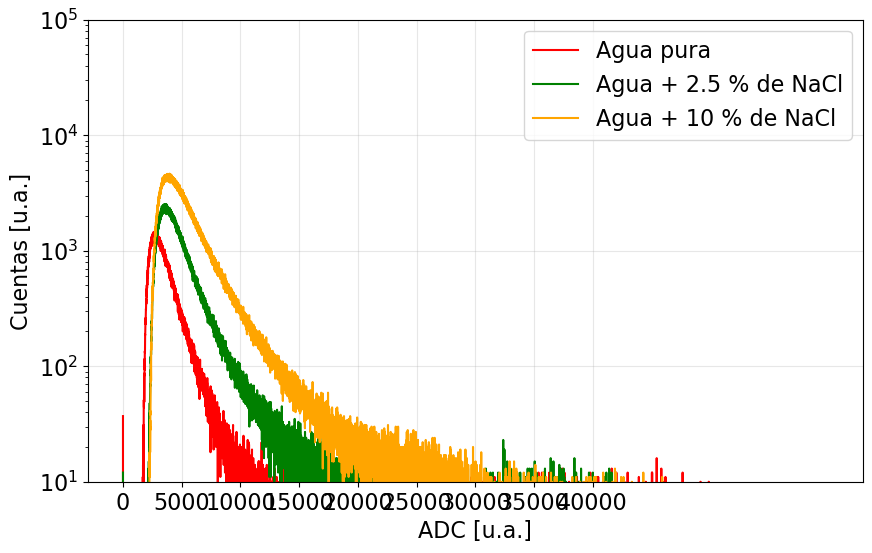

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN GENERAL
# -------------------------------------
CONFIGS = {
    "Agua pura": ("pura_fondo.dat", "pura_neutrones.dat", "red"),
    "Agua + 2.5 % de NaCl": ("2.5_fondo.dat", "2.5_neutrones.dat", "green"),
    "Agua + 10 % de NaCl": ("10_fondo.dat", "10_neutrones.dat", "orange")
}

OUTDIR = "Comparacion-tres-configuraciones"
os.makedirs(OUTDIR, exist_ok=True)

CHANNEL = 0
BINS = 9000
RANGE_MIN = 0
RANGE_MAX = 60000

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()
            if line == "":
                continue
            if line.startswith("#"):
                if line.startswith("# t"):
                    if current:
                        yield np.array(current, dtype=float)
                        current = []
                continue
            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0]); b = float(parts[1])
                    current.append((a, b))
                except:
                    continue
        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []
    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]
        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])
        signal = ch - baseline
        pos = signal.copy()
        pos[pos < 0] = 0.0
        charges.append(pos.sum())
    return np.array(charges)

# -------------------------------------
# PROCESAR TODAS LAS CONFIGURACIONES
# -------------------------------------

plt.figure(figsize=(10, 6))

for name, (fondo_file, neut_file, color) in CONFIGS.items():

    # Cargar cargas
    charges_fondo = compute_charges(fondo_file)
    charges_neut = compute_charges(neut_file)

    # Histograma
    counts_fondo, edges = np.histogram(
        charges_fondo, bins=BINS, range=(RANGE_MIN, RANGE_MAX)
    )
    counts_neut, _ = np.histogram(
        charges_neut, bins=BINS, range=(RANGE_MIN, RANGE_MAX)
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    # Diferencia
    diff = counts_neut - counts_fondo

    # Guardar datos de diferencias
    out_data = os.path.join(OUTDIR, f"diferencia_{name}.txt")
    np.savetxt(out_data, np.column_stack((centers, diff)),
               header="centro_bin   diferencia_counts")

    print(f"Archivo guardado: {out_data}")

    # Graficar diferencias
    plt.plot(centers, diff, lw=1.5, color=color, label=name.replace("_", " "))

# -------------------------------------
# CONFIGURACIÓN DE LA GRÁFICA FINAL
# -------------------------------------
plt.xscale("linear")
plt.yscale("log")

plt.xlabel("ADC [u.a.]", fontsize=16)
plt.ylabel("Cuentas [u.a.]", fontsize=16)

plt.title("", fontsize=16)
plt.grid(alpha=0.3)

#plt.xlim(0, 40000)
plt.ylim(10, 1e5)

plt.legend(fontsize=16)
# ✔️ NUEVO: intervalos de 5000 en el eje X
plt.xticks(np.arange(0, 40001, 5000))
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)

# Nombre del archivo PNG
out_plot = os.path.join(
    OUTDIR,
    "Comparacion-3-configuraciones-2.png"
)

# Nombre del archivo PDF
out_plot_pdf = os.path.join(
    OUTDIR,
    "Comparacion-3-configuraciones-2.pdf"
)

# Guardar PNG
fig.savefig(
    out_plot,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

# Guardar PDF
fig.savefig(
    out_plot_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03
)

plt.close(fig)

print(f"Figura PNG guardada en: {out_plot}")
print(f"Figura PDF guardada en: {out_plot_pdf}")


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------
# CONFIGURACIÓN GENERAL
# -------------------------------------
CONFIGS = {
    "Agua pura": ("pura_fondo.dat", "pura_neutrones.dat", "red"),
    "Agua + 2.5 % de NaCl": ("2.5_fondo.dat", "2.5_neutrones.dat", "green"),
    "Agua + 10 % de NaCl": ("10_fondo.dat", "10_neutrones.dat", "orange")
}

OUTDIR = "Comparacion-tres-configuraciones"
os.makedirs(OUTDIR, exist_ok=True)

CHANNEL = 0

# Mismo binning usado en Exp vs Sim
BIN_START = 1200.0
BIN_END = 189700.0
BIN_WIDTH = 20.0

BIN_EDGES = np.arange(BIN_START, BIN_END + BIN_WIDTH, BIN_WIDTH)
BINS = len(BIN_EDGES) - 1

print("Número de bins =", BINS)
print("Número de bordes =", len(BIN_EDGES))
print("Borde inicial =", BIN_EDGES[0])
print("Borde final =", BIN_EDGES[-1])
print("Ancho de bin =", BIN_EDGES[1] - BIN_EDGES[0])

# -------------------------------------
# PARSER DE EVENTOS LAGO v5
# -------------------------------------
def parse_events_stream(filename):
    current = []
    with open(filename, "r") as f:
        for raw in f:
            line = raw.strip()

            if line == "":
                continue

            if line.startswith("#"):
                if line.startswith("# t") and current:
                    yield np.array(current, dtype=float)
                    current = []
                continue

            parts = line.split()
            if len(parts) >= 2:
                try:
                    a = float(parts[0])
                    b = float(parts[1])
                    current.append((a, b))
                except ValueError:
                    continue

        if current:
            yield np.array(current, dtype=float)

# -------------------------------------
# FUNCIÓN PARA OBTENER CARGAS POSITIVAS
# -------------------------------------
def compute_charges(filename):
    charges = []

    for ev in parse_events_stream(filename):
        ch = ev[:, CHANNEL]

        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])

        signal = ch - baseline
        signal[signal < 0] = 0.0

        charges.append(signal.sum())

    return np.array(charges)

# -------------------------------------
# PROCESAR TODAS LAS CONFIGURACIONES
# -------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for name, (fondo_file, neut_file, color) in CONFIGS.items():

    charges_fondo = compute_charges(fondo_file)
    charges_neut = compute_charges(neut_file)

    counts_fondo, _ = np.histogram(
        charges_fondo,
        bins=BIN_EDGES
    )

    counts_neut, _ = np.histogram(
        charges_neut,
        bins=BIN_EDGES
    )

    centers = 0.5 * (BIN_EDGES[:-1] + BIN_EDGES[1:])

    # Diferencia fuente+fondo menos fondo
    diff = counts_neut - counts_fondo

    out_data = os.path.join(
        OUTDIR,
        f"diferencia_{name.replace(' ', '_').replace('%','pct')}.txt"
    )

    np.savetxt(
        out_data,
        np.column_stack((centers, diff)),
        header="centro_bin_ADC   diferencia_counts"
    )

    print(f"Archivo guardado: {out_data}")

    # Para escala logarítmica solo se grafican valores positivos
    diff_plot = np.where(diff > 0, diff, np.nan)

    ax.plot(
        centers,
        diff_plot,
        lw=1.5,
        color=color,
        label=name
    )

# -------------------------------------
# CONFIGURACIÓN DE LA GRÁFICA FINAL
# -------------------------------------
ax.set_yscale("log")
ax.set_xlim(0, 40000)
ax.set_ylim(10, 1e5)

ax.set_xlabel("Carga integrada [ADC]", fontsize=30)
ax.set_ylabel("Número de cuentas por bin", fontsize=30)

ax.set_xticks(np.arange(0, 40001, 5000))

ax.tick_params(axis="both", which="major", labelsize=26)
ax.tick_params(axis="both", which="minor", labelsize=26)

ax.grid(True, which="major", alpha=0.35)
ax.grid(True, which="minor", alpha=0.15)

ax.legend(
    fontsize=26,
    loc="upper right",
    frameon=True,
    framealpha=0.92
)

# Ruta del archivo PNG
out_plot = os.path.join(
    OUTDIR,
    "Comparacion-3-configuraciones-bins9425.png"
)

# Ruta del archivo PDF
out_plot_pdf = os.path.join(
    OUTDIR,
    "Comparacion-3-configuraciones-bins9425.pdf"
)

# Guardar en PNG
fig.savefig(
    out_plot,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03
)

# Guardar en PDF
fig.savefig(
    out_plot_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03
)

# Cerrar solamente después de guardar ambos archivos
plt.close(fig)

print(f"\nFigura PNG guardada en: {out_plot}")
print(f"Figura PDF guardada en: {out_plot_pdf}")

Número de bins = 9425
Número de bordes = 9426
Borde inicial = 1200.0
Borde final = 189700.0
Ancho de bin = 20.0
Archivo guardado: Comparacion-tres-configuraciones/diferencia_Agua_pura.txt
Archivo guardado: Comparacion-tres-configuraciones/diferencia_Agua_+_2.5_pct_de_NaCl.txt
Archivo guardado: Comparacion-tres-configuraciones/diferencia_Agua_+_10_pct_de_NaCl.txt

Figura PNG guardada en: Comparacion-tres-configuraciones/Comparacion-3-configuraciones-bins9425.png
Figura PDF guardada en: Comparacion-tres-configuraciones/Comparacion-3-configuraciones-bins9425.pdf


In [17]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter


# ==========================================================
# CONFIGURACIÓN GENERAL
# ==========================================================

CONFIGS = {
    "Agua pura": {
        "fondo": "pura_fondo.dat",
        "fuente": "pura_neutrones.dat",
        "color": "#C62828",
        "id": "agua_pura"
    },

    "Agua + 2.5 % de NaCl": {
        "fondo": "2.5_fondo.dat",
        "fuente": "2.5_neutrones.dat",
        "color": "#2E7D32",
        "id": "agua_2p5_NaCl"
    },

    "Agua + 10 % de NaCl": {
        "fondo": "10_fondo.dat",
        "fuente": "10_neutrones.dat",
        "color": "#D97706",
        "id": "agua_10_NaCl"
    }
}

OUTDIR = "Comparacion-tres-configuraciones"
os.makedirs(OUTDIR, exist_ok=True)

CHANNEL = 0


# ==========================================================
# BINNING ORIGINAL
# ==========================================================
# Este binning se conserva para todos los cálculos y para
# los archivos de datos originales.

BIN_START = 1200.0
BIN_END = 189700.0
BIN_WIDTH = 20.0

BIN_EDGES = np.arange(
    BIN_START,
    BIN_END + BIN_WIDTH,
    BIN_WIDTH
)

BINS = len(BIN_EDGES) - 1


# ==========================================================
# AGRUPAMIENTO SOLO PARA LA FIGURA
# ==========================================================
# Se agrupan cinco bins originales:
#
# 5 × 20 ADC = 100 ADC por bin gráfico.
#
# Los datos originales de 20 ADC no son modificados.

DISPLAY_REBIN = 5

DISPLAY_BIN_WIDTH = BIN_WIDTH * DISPLAY_REBIN


# ==========================================================
# LÍMITES DE LA FIGURA
# ==========================================================

XLIM = (1200, 30000)
YLIM = (10, 1e5)

XTICK_STEP = 5000


print("\nConfiguración del histograma original")
print("-------------------------------------")
print(f"Número de bins       = {BINS}")
print(f"Número de bordes     = {len(BIN_EDGES)}")
print(f"Borde inicial        = {BIN_EDGES[0]:.1f} ADC")
print(f"Borde final          = {BIN_EDGES[-1]:.1f} ADC")
print(f"Ancho original       = {BIN_WIDTH:.1f} ADC")
print(f"Factor gráfico       = {DISPLAY_REBIN}")
print(f"Ancho gráfico        = {DISPLAY_BIN_WIDTH:.1f} ADC")


# ==========================================================
# PARSER DE EVENTOS LAGO v5
# ==========================================================

def parse_events_stream(filename):
    """
    Lee secuencialmente un archivo de eventos LAGO v5.

    Cada evento se devuelve como un arreglo NumPy de dos
    columnas. Las líneas iniciadas con '# t' delimitan los
    diferentes eventos.
    """

    current = []

    with open(filename, "r", encoding="utf-8") as file:

        for raw_line in file:

            line = raw_line.strip()

            if not line:
                continue

            if line.startswith("#"):

                if line.startswith("# t") and current:
                    yield np.asarray(current, dtype=float)
                    current = []

                continue

            parts = line.split()

            if len(parts) < 2:
                continue

            try:
                value_a = float(parts[0])
                value_b = float(parts[1])

                current.append((value_a, value_b))

            except ValueError:
                continue

        if current:
            yield np.asarray(current, dtype=float)


# ==========================================================
# CÁLCULO DE CARGA INTEGRADA
# ==========================================================

def compute_charges(filename):
    """
    Calcula la carga integrada positiva de cada evento.

    El baseline se estima mediante la mediana de las primeras
    20 muestras, o de todas las muestras disponibles cuando
    el evento contiene menos de 20.
    """

    charges = []

    for event in parse_events_stream(filename):

        if event.size == 0:
            continue

        channel_data = event[:, CHANNEL]

        number_baseline_samples = min(
            20,
            len(channel_data)
        )

        baseline = np.median(
            channel_data[:number_baseline_samples]
        )

        signal = channel_data - baseline

        # Solo se integra la contribución positiva.
        signal = np.clip(
            signal,
            a_min=0.0,
            a_max=None
        )

        integrated_charge = np.sum(signal)

        charges.append(integrated_charge)

    return np.asarray(charges, dtype=float)


# ==========================================================
# AGRUPAMIENTO DE BINS
# ==========================================================

def rebin_counts(counts, centers, factor):
    """
    Agrupa bins consecutivos sumando sus cuentas.

    Este procedimiento se aplica exclusivamente a la
    representación gráfica. Los histogramas originales
    permanecen sin modificar.
    """

    if factor <= 1:
        return counts.copy(), centers.copy()

    usable_bins = (
        len(counts) // factor
    ) * factor

    counts_trimmed = counts[:usable_bins]
    centers_trimmed = centers[:usable_bins]

    rebinned_counts = counts_trimmed.reshape(
        -1,
        factor
    ).sum(axis=1)

    rebinned_centers = centers_trimmed.reshape(
        -1,
        factor
    ).mean(axis=1)

    return rebinned_counts, rebinned_centers


# ==========================================================
# CONFIGURACIÓN GRÁFICA
# ==========================================================

def configure_axes(ax):
    """
    Aplica un estilo uniforme adecuado para tesis y
    publicación científica.
    """

    ax.set_yscale("log")

    ax.set_xlim(*XLIM)
    ax.set_ylim(*YLIM)

    ax.set_xlabel(
        "Carga integrada [ADC]",
        fontsize=21
    )

    ax.set_ylabel(
        f"Exceso de cuentas por bin ({DISPLAY_BIN_WIDTH:.0f} ADC)",
        fontsize=21
    )

    ax.set_xticks(
        np.arange(
            5000,
            XLIM[1] + 1,
            XTICK_STEP
        )
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=17,
        length=6,
        width=1.0
    )

    ax.tick_params(
        axis="both",
        which="minor",
        length=3,
        width=0.7
    )

    # Divisiones principales del eje logarítmico.
    ax.yaxis.set_major_locator(
        LogLocator(
            base=10.0,
            numticks=7
        )
    )

    # Se conservan marcas menores, pero sin etiquetas.
    ax.yaxis.set_minor_locator(
        LogLocator(
            base=10.0,
            subs=(2, 5),
            numticks=12
        )
    )

    ax.yaxis.set_minor_formatter(
        NullFormatter()
    )

    # Solo cuadrícula principal para reducir saturación.
    ax.grid(
        True,
        which="major",
        linestyle="-",
        linewidth=0.75,
        alpha=0.22
    )

    ax.grid(
        False,
        which="minor"
    )

    for spine in ax.spines.values():
        spine.set_linewidth(1.0)


# ==========================================================
# CREAR FIGURA
# ==========================================================

fig, ax = plt.subplots(
    figsize=(12, 7),
    constrained_layout=True
)

original_centers = 0.5 * (
    BIN_EDGES[:-1] + BIN_EDGES[1:]
)


# ==========================================================
# PROCESAR LAS TRES CONFIGURACIONES
# ==========================================================

for name, config in CONFIGS.items():

    fondo_file = config["fondo"]
    fuente_file = config["fuente"]
    color = config["color"]
    config_id = config["id"]

    print(f"\nProcesando: {name}")

    charges_fondo = compute_charges(
        fondo_file
    )

    charges_fuente = compute_charges(
        fuente_file
    )

    print(
        f"  Eventos de fondo:          "
        f"{len(charges_fondo)}"
    )

    print(
        f"  Eventos fuente + fondo:    "
        f"{len(charges_fuente)}"
    )

    # ------------------------------------------------------
    # Histogramas con el mismo conjunto de bordes
    # ------------------------------------------------------

    counts_fondo, _ = np.histogram(
        charges_fondo,
        bins=BIN_EDGES
    )

    counts_fuente, _ = np.histogram(
        charges_fuente,
        bins=BIN_EDGES
    )

    # ------------------------------------------------------
    # Diferencia original bin a bin
    # ------------------------------------------------------

    difference_original = (
        counts_fuente - counts_fondo
    )

    # ------------------------------------------------------
    # Guardar diferencia original
    # ------------------------------------------------------

    original_data_path = os.path.join(
        OUTDIR,
        f"diferencia_original_{config_id}_bins{BINS}.dat"
    )

    np.savetxt(
        original_data_path,
        np.column_stack(
            (
                original_centers,
                difference_original
            )
        ),
        fmt=["%.3f", "%d"],
        delimiter="\t",
        header=(
            "centro_bin_ADC\t"
            "diferencia_fuente_mas_fondo_menos_fondo"
        )
    )

    print(
        f"  Datos originales guardados en:\n"
        f"  {original_data_path}"
    )

    # ------------------------------------------------------
    # Agrupamiento únicamente para la gráfica
    # ------------------------------------------------------

    difference_display, display_centers = rebin_counts(
        difference_original,
        original_centers,
        DISPLAY_REBIN
    )

    # Guardar también los datos agrupados.
    display_data_path = os.path.join(
        OUTDIR,
        f"diferencia_grafica_{config_id}_"
        f"bin{DISPLAY_BIN_WIDTH:.0f}ADC.dat"
    )

    np.savetxt(
        display_data_path,
        np.column_stack(
            (
                display_centers,
                difference_display
            )
        ),
        fmt=["%.3f", "%d"],
        delimiter="\t",
        header=(
            "centro_bin_ADC\t"
            "diferencia_agrupada_fuente_mas_fondo_menos_fondo"
        )
    )

    # ------------------------------------------------------
    # Solo valores positivos en la escala logarítmica
    # ------------------------------------------------------

    difference_plot = np.where(
        difference_display > 0,
        difference_display,
        np.nan
    )

    # ------------------------------------------------------
    # Dibujar la curva
    # ------------------------------------------------------

    ax.plot(
        display_centers,
        difference_plot,
        linewidth=2.1,
        color=color,
        label=name,
        solid_capstyle="round",
        solid_joinstyle="round",
        zorder=3
    )


# ==========================================================
# ESTILO FINAL
# ==========================================================

configure_axes(ax)

legend = ax.legend(
    title="Medio detector",
    fontsize=15,
    title_fontsize=15,
    loc="upper right",
    frameon=True,
    framealpha=0.96,
    edgecolor="0.75",
    handlelength=2.8,
    borderpad=0.6,
    labelspacing=0.5
)

legend.get_frame().set_linewidth(0.8)


# ==========================================================
# GUARDAR PNG Y PDF
# ==========================================================

base_output = os.path.join(
    OUTDIR,
    "Comparacion-3-configuraciones-mejorada"
)

output_png = base_output + ".png"
output_pdf = base_output + ".pdf"

fig.savefig(
    output_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.04
)

fig.savefig(
    output_pdf,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.04
)

plt.close(fig)

print("\nProcesamiento finalizado correctamente.")
print(f"Figura PNG guardada en: {output_png}")
print(f"Figura PDF guardada en: {output_pdf}")


Configuración del histograma original
-------------------------------------
Número de bins       = 9425
Número de bordes     = 9426
Borde inicial        = 1200.0 ADC
Borde final          = 189700.0 ADC
Ancho original       = 20.0 ADC
Factor gráfico       = 5
Ancho gráfico        = 100.0 ADC

Procesando: Agua pura
  Eventos de fondo:          125401
  Eventos fuente + fondo:    563961
  Datos originales guardados en:
  Comparacion-tres-configuraciones/diferencia_original_agua_pura_bins9425.dat

Procesando: Agua + 2.5 % de NaCl
  Eventos de fondo:          114227
  Eventos fuente + fondo:    1099688
  Datos originales guardados en:
  Comparacion-tres-configuraciones/diferencia_original_agua_2p5_NaCl_bins9425.dat

Procesando: Agua + 10 % de NaCl
  Eventos de fondo:          185751
  Eventos fuente + fondo:    2488416
  Datos originales guardados en:
  Comparacion-tres-configuraciones/diferencia_original_agua_10_NaCl_bins9425.dat

Procesamiento finalizado correctamente.
Figura PNG guardad

In [107]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# ---------- USER ----------
FILENAME = "2.5_fondo.dat"   # pon aquí tu RAW procesado o el archivo con cargas por evento
# Si ya tienes "charges.txt" (una columna por evento), pon su ruta aquí y activa USE_CHARGES_FILE
USE_CHARGES_FILE = False
CHARGES_FILE = "out/charges.txt"

CHANNEL = 0          # 0 o 1 si lees raw samples por evento
N_TOP = 20           # cuántos eventos grandes listar
OUTDIR = "Agua+25NaCl-fondo"
os.makedirs(OUTDIR, exist_ok=True)
# --------------------------

# Si ya tienes un archivo con cargas por evento (una columna), usa esto:
if USE_CHARGES_FILE:
    charges = np.loadtxt(CHARGES_FILE)
else:
    # Si no, parseamos el RAW LAGO v5 (events terminan en líneas "# t")
    def parse_events_stream(filename):
        current = []
        with open(filename, "r") as f:
            for raw in f:
                line = raw.strip()
                if line == "":
                    continue
                if line.startswith("#"):
                    if line.startswith("# t"):
                        if current:
                            yield np.array(current, dtype=float)
                            current = []
                    continue
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        a = float(parts[0]); b = float(parts[1])
                        current.append((a,b))
                    except:
                        continue
            if current:
                yield np.array(current, dtype=float)

    # procesar eventos: generar cargas con varias estrategias
    events = []
    charges_pos = []   # integrate positive only
    charges_full = []  # full sum (signal)
    peaks = []
    max_sample_values = []
    for idx,ev in enumerate(parse_events_stream(FILENAME)):
        ch = ev[:, CHANNEL]
        # baseline robusta (median of first 20)
        nb = min(20, len(ch))
        baseline = np.median(ch[:nb])
        signal = ch - baseline
        # positive-only
        pos = signal.copy(); pos[pos < 0] = 0.0
        q_pos = pos.sum()
        q_full = signal.sum()
        peak_val = signal.max()
        events.append(signal)
        charges_pos.append(q_pos)
        charges_full.append(q_full)
        peaks.append(peak_val)
        max_sample_values.append(ch.max())

    charges = np.array(charges_pos)
    charges_full = np.array(charges_full)
    peaks = np.array(peaks)
    max_sample_values = np.array(max_sample_values)
    print(f"Processed {len(charges)} events.")

# ---------- Basic stats ----------
def print_stats(arr, name="charges"):
    print(f"--- {name} stats ---")
    print(f"count: {len(arr)}")
    for p in [50, 90, 95, 99, 99.5, 100]:
        print(f"P{p}: {np.percentile(arr, p):.2f}")
    print(f"mean: {arr.mean():.2f}, max: {arr.max():.2f}")
print_stats(charges, "charges (positive-only)")
print_stats(charges_full, "charges (full)")

# ---------- Top events ----------
top_idx = np.argsort(charges)[-N_TOP:][::-1]
with open(os.path.join(OUTDIR,"top_events.txt"), "w") as fo:
    fo.write("rank\tidx\tcharge_pos\tcharge_full\tpeak_val\tmax_sample\n")
    for r,i in enumerate(top_idx,1):
        fo.write(f"{r}\t{i}\t{charges[i]:.3f}\t{charges_full[i]:.3f}\t{peaks[i]:.3f}\t{max_sample_values[i]:.1f}\n")
print(f"Wrote top {N_TOP} events to {OUTDIR}/top_events.txt")

# ---------- Check saturation (samples at ADC max) ----------
global_max_sample = max_sample_values.max()
print("Global max sample value:", global_max_sample)
# guess typical ADC dynamic range if integer: check if values near 2^12,2^14 etc
for candidate in [4095, 8191, 16383, 32767]:
    n_eq = np.sum(max_sample_values >= candidate)
    if n_eq>0:
        print(f"Found {n_eq} events with sample >= {candidate} (possible saturation)")

# ---------- Plot histogram (wide range) ----------
plt.figure(figsize=(8,5))
bins = 1000
xmax=60001
maxrange = max(80000, charges.max()*1.2)
counts, edges = np.histogram(charges, bins=bins, range=(0, maxrange))
centers = 0.5*(edges[:-1]+edges[1:])
#plt.plot(centers, counts, '-', lw=1)
    #plt.plot(centers, counts, lw=1.2)
plt.plot(centers, counts, lw=1.2, color="grey")


plt.yscale("log")
    #plt.xlabel("ADC [u.a]")
    #plt.ylabel("Cuentas [u.a.]")
plt.xlabel("ADC [u.a]", fontsize=16)
plt.xlim(0, 40001)
    #plt.ylim(1e-4, 2)
plt.ylabel("Cuentas [u.a.]", fontsize=16)
plt.title("", fontsize=16)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)


plt.title("")

plt.grid(alpha=0.3)
#plt.xticks(np.arange(0, xmax, 10000))
plt.xticks(np.arange(0, xmax, 10000), fontsize=16)
#ax = plt.gca()
#ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.savefig(os.path.join(OUTDIR,"Histograma-fondo-Agua-25NaCl.png"), dpi=150)
plt.close()

# also full charges
plt.figure(figsize=(9,4))
counts_f, edges_f = np.histogram(charges_full, bins=bins, range=(0,maxrange))
plt.plot(0.5*(edges_f[:-1]+edges_f[1:]), counts_f, '-', lw=1, color='orange')
plt.yscale("log")
plt.xlabel("Integrated charge (ADU) - full")
plt.ylabel("Counts")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTDIR,"hist_charges_full.png"), dpi=150)
plt.close()

# ---------- ECDF to see tail fraction ----------
sorted_ch = np.sort(charges)
ecdf_y = np.linspace(0,1,len(sorted_ch))
plt.figure(figsize=(6,4))
plt.plot(sorted_ch, ecdf_y)
plt.xscale("linear")
plt.xlabel("Integrated charge (ADU)")
plt.ylabel("Cumulative fraction")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUTDIR,"ecdf_charges.png"), dpi=150)
plt.close()

# ---------- Plot raw pulses for top events ----------
import matplotlib
for rank,i in enumerate(top_idx):
    sig = events[i]
    plt.figure(figsize=(6,3))
    plt.plot(sig, lw=1)
    plt.axhline(0, color='k', lw=0.6)
    plt.title(f"Top{rank+1} event idx={i} charge={charges[i]:.1f}")
    plt.xlabel("sample")
    plt.ylabel("ADC - baseline")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR,f"pulse_top_{rank+1}_idx_{i}.png"), dpi=150)
    plt.close()

print("Diagnostic plots and files saved in", OUTDIR)


Processed 114227 events.
--- charges (positive-only) stats ---
count: 114227
P50: 9228.00
P90: 38726.00
P95: 42587.00
P99: 49147.48
P99.5: 50781.61
P100: 74214.00
mean: 16486.42, max: 74214.00
--- charges (full) stats ---
count: 114227
P50: 7685.00
P90: 32676.00
P95: 36272.00
P99: 41722.74
P99.5: 43430.35
P100: 64227.00
mean: 12686.28, max: 64227.00
Wrote top 20 events to Agua+25NaCl-fondo/top_events.txt
Global max sample value: 8050.0
Found 46761 events with sample >= 4095 (possible saturation)
Diagnostic plots and files saved in Agua+25NaCl-fondo


Pulsos extraídos: 114227
Valores máximos de carga detectados: 78653.90000000002


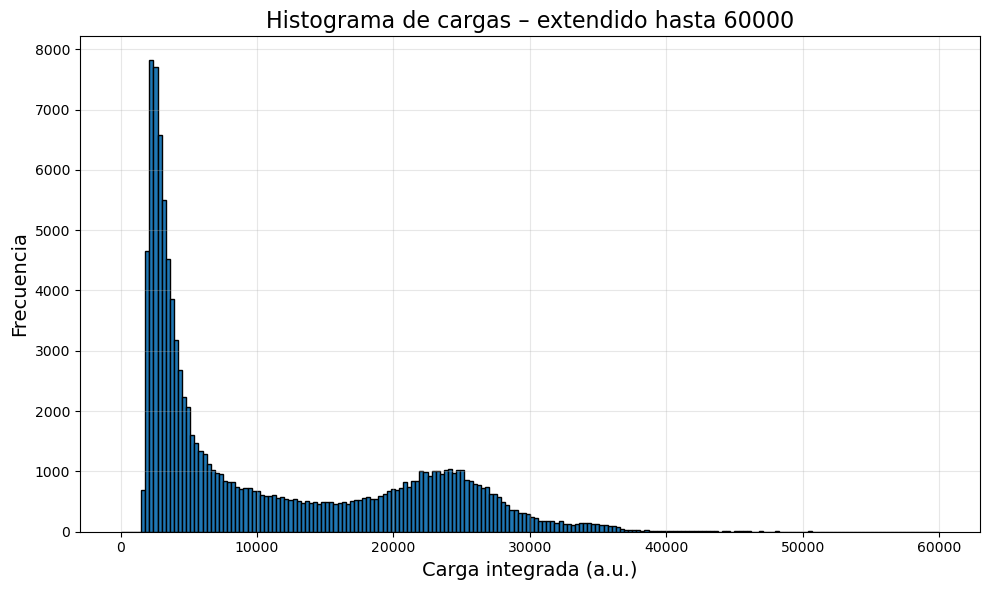

In [73]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
#  A. LECTOR DEL ARCHIVO RAW LAGO v5
# ============================================================


def read_lago_raw_v5(filepath):
    """
    Retorna una lista de pulsos.
    Cada pulso = lista de muestras [ [ADC1, ADC2], ... ]
    """
    pulses = []
    current_pulse = []

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()

            # salto líneas de comentario
            if line.startswith("#") or line == "":
                # fin de pulso
                if line.startswith("# t") and len(current_pulse) > 0:
                    pulses.append(np.array(current_pulse, dtype=int))
                    current_pulse = []
                continue

            # Línea de datos ADC: "  132   95"
            parts = line.split()
            if len(parts) == 2:
                try:
                    a1 = int(parts[0])
                    a2 = int(parts[1])
                    current_pulse.append([a1, a2])
                except:
                    pass

    # Agregar último pulso si quedó sin cerrar
    if len(current_pulse) > 0:
        pulses.append(np.array(current_pulse, dtype=int))

    return pulses


# ============================================================
#  B. PROCESAMIENTO: CÁLCULO DE CARGA
# ============================================================

def compute_charge(pulse, channel=0, baseline_samples=20):
    """
    Integra el pulso del canal indicado.
    """
    samples = pulse[:, channel]

    # Baseline = promedio primeros N
    baseline = np.mean(samples[:baseline_samples])

    # Pulso corregido
    corrected = samples - baseline

    # Solo valores positivos (evita ruido negativo)
    corrected = corrected[corrected > 0]

    if len(corrected) == 0:
        return 0

    # Integración simple
    charge = np.sum(corrected)

    return charge


# ============================================================
#  C. PROGRAMA PRINCIPAL
# ============================================================

FILE = "2.5_fondo.dat"     # <-- cámbialo

pulses = read_lago_raw_v5(FILE)
print("Pulsos extraídos:", len(pulses))

charges = []

for i, pulse in enumerate(pulses):
    Q = compute_charge(pulse, channel=0)  # canal 0 = ADC1
    charges.append(Q)

charges = np.array(charges)

print("Valores máximos de carga detectados:", np.max(charges))


# ============================================================
#  D. HISTOGRAMA EXTENDIDO HASTA 60000
# ============================================================

plt.figure(figsize=(10,6))

plt.hist(charges, bins=200, range=(0,60000), edgecolor='black')

plt.title("Histograma de cargas – extendido hasta 60000", fontsize=16)
plt.xlabel("Carga integrada (a.u.)", fontsize=14)
plt.ylabel("Frecuencia", fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# === Leer los datos desde el archivo ===
# El archivo debe tener dos columnas:
# E(MeV)   RelativeFlux(normalized)
data = np.loadtxt("espectro-neutrones-Am-Be-241.txt", comments="#")

# === Separar columnas ===
E = data[:, 0]     # Energía (MeV)
flux = data[:, 1]  # Flujo relativo (normalizado)

# === Graficar ===
plt.figure(figsize=(8,5))
plt.plot(E, flux, color='royalblue', lw=2)
plt.title("Espectro de neutrones — Fuente 241Am–Be")
plt.xlabel("Energía del neutrón (MeV)")
plt.ylabel("Flujo relativo (normalizado)")
plt.grid(True, alpha=0.3)
plt.xlim(0, 11)
plt.ylim(0, 0.4)

# === Marcar el pico principal ===
E_max = E[np.argmax(flux)]
plt.axvline(E_max, color='gray', linestyle='--', alpha=0.5)
plt.text(E_max + 0.2, max(flux) * 0.9, f"Pico ≈ {E_max:.2f} MeV", fontsize=10)

plt.tight_layout()
plt.show()


ValueError: could not convert string '0,10327022375215167;' to float64 at row 0, column 1.

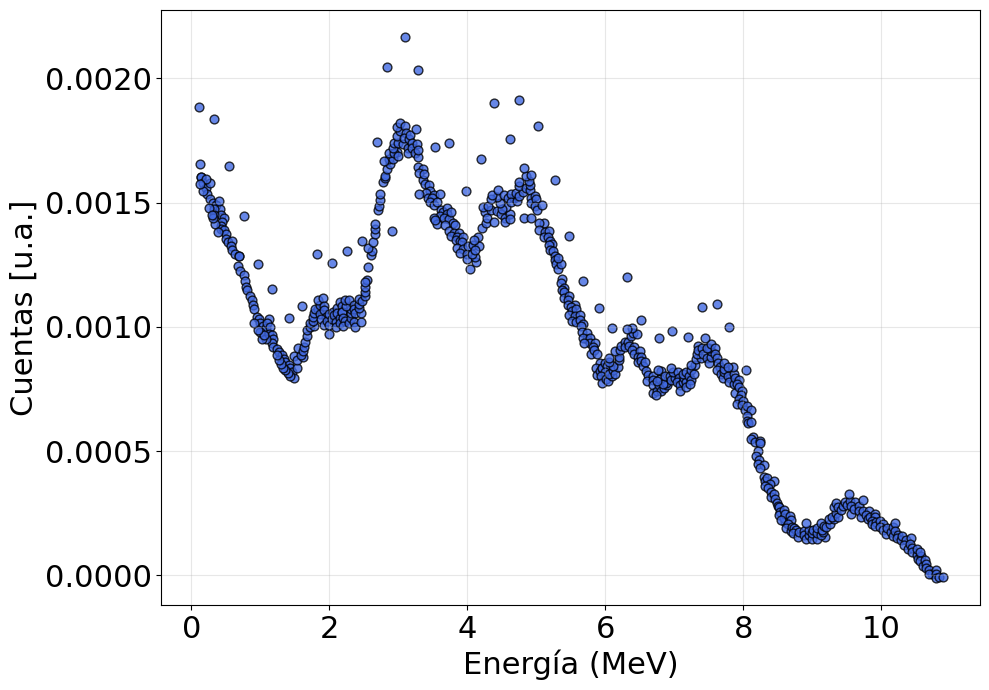

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# === 1. Leer el archivo original y reemplazar comas por puntos ===
input_file = "espectro-neutrones-Am-Be-241.txt"
clean_file = "espectro-neutrones-Am-Be-241-clean.txt"

# Reemplaza comas decimales por puntos
with open(input_file, "r") as f:
    text = f.read().replace(",", ".")
with open(clean_file, "w") as f:
    f.write(text)

# === 2. Leer los datos corregidos ===
data = np.loadtxt(clean_file, delimiter=';')

# === 3. Separar columnas ===
E = data[:, 0]
flux = data[:, 1]

# === 4. Graficar solo los puntos ===
plt.figure(figsize=(10,7))
plt.scatter(E, flux, color='royalblue', s=40, edgecolor='k', alpha=0.8)
plt.title("", fontsize=13)
plt.xlabel("Energía (MeV)", fontsize=22)
plt.ylabel("Cuentas [u.a.]", fontsize=22)
plt.grid(True, alpha=0.3)
plt.tick_params(axis='x', which='both', labelsize=22)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=22)  # Tics mayores
plt.tight_layout()
plt.savefig('espectro-energia-Am-Be-241.png', dpi=300)
plt.savefig('espectro-energia-Am-Be-241.pdf')

plt.show()


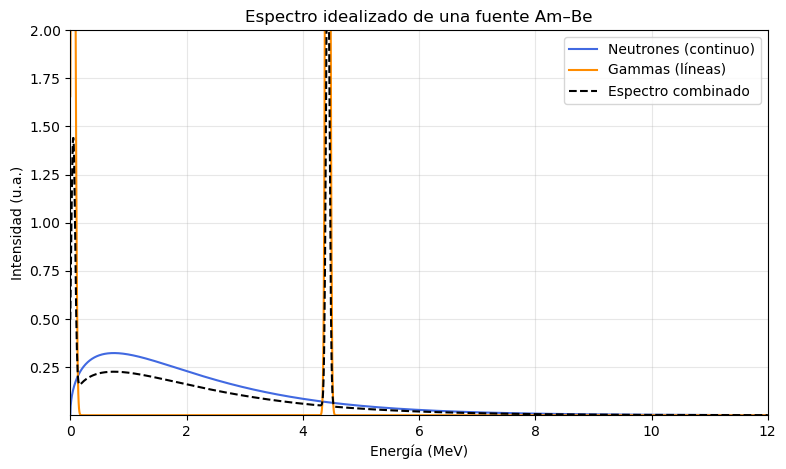

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# === Energía (MeV) ===
E = np.linspace(0, 12, 2000)

# === Espectro de neutrones AmBe ===
# Aproximación tipo Maxwelliana (P(E) ~ sqrt(E) * exp(-E/T))
Tn = 1.5  # parámetro de "temperatura" (MeV)
neutron_spectrum = np.sqrt(E) * np.exp(-E / Tn)
neutron_spectrum /= np.trapz(neutron_spectrum, E)  # normalización

# === Espectro gamma ===
gamma_lines = [
    (0.026, 0.2),   # 26 keV
    (0.0595, 0.4),  # 59.5 keV (Am-241)
    (4.43, 1.0)     # 4.43 MeV (C-12)
]

gamma_spectrum = np.zeros_like(E)
for energy, intensity in gamma_lines:
    gamma_spectrum += intensity * np.exp(-0.5 * ((E - energy) / 0.03)**2)

gamma_spectrum /= np.trapz(gamma_spectrum, E)

# === Espectro total (normalizado) ===
total_spectrum = 0.7 * neutron_spectrum + 0.3 * gamma_spectrum

# === Gráfica ===
plt.figure(figsize=(9,5))
plt.plot(E, neutron_spectrum, label="Neutrones (continuo)", color="royalblue")
plt.plot(E, gamma_spectrum, label="Gammas (líneas)", color="darkorange")
plt.plot(E, total_spectrum, label="Espectro combinado", color="black", linestyle="--")

plt.xlabel("Energía (MeV)")
plt.ylabel("Intensidad (u.a.)")
plt.title("Espectro idealizado de una fuente Am–Be")
#plt.yscale("log")
plt.xlim(0, 12)
plt.ylim(1e-4, 2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


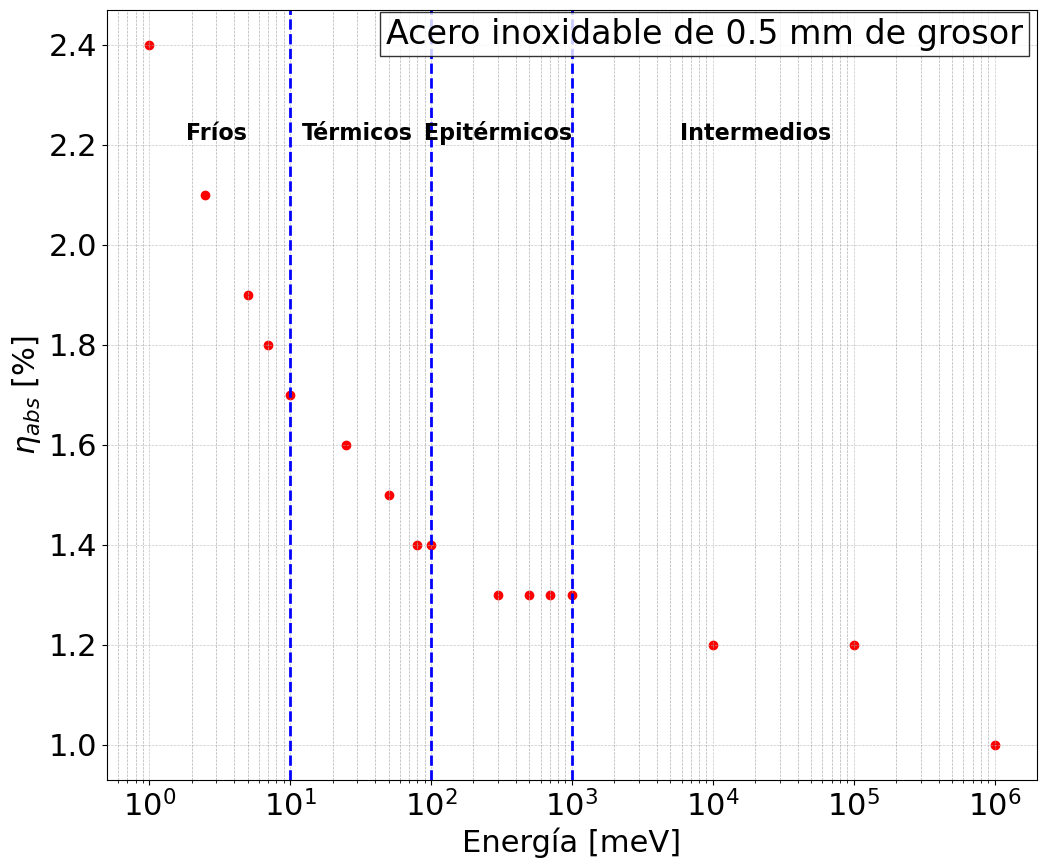

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
energia = np.array([
    1, 2.5, 5, 7, 10, 25, 50, 80, 100, 300,
    500, 700, 1000, 10000, 100000, 1000000
])

abs_acero = np.array([
    2.4, 2.1, 1.9, 1.8, 1.7, 1.6,
    1.5, 1.4, 1.4, 1.3, 1.3, 1.3,
    1.3, 1.2, 1.2, 1.0
])

# Crear figura
plt.figure(figsize=(12, 10))

# Graficar puntos
plt.scatter(energia, abs_acero, color='red')

# Líneas verticales que delimitan las regiones de energía
plt.axvline(x=10, color='blue', linestyle='--', linewidth=2)
plt.axvline(x=100, color='blue', linestyle='--', linewidth=2)
plt.axvline(x=1000, color='blue', linestyle='--', linewidth=2)

# Agregar etiquetas para cada región en la parte superior
plt.text(3, 2.2, 'Fríos', fontsize=16, ha='center', va='bottom', fontweight='bold')
plt.text(30, 2.2, 'Térmicos', fontsize=16, ha='center', va='bottom', fontweight='bold')
plt.text(300, 2.2, 'Epitérmicos', fontsize=16, ha='center', va='bottom', fontweight='bold')
plt.text(20000, 2.2, 'Intermedios', fontsize=16, ha='center', va='bottom', fontweight='bold')


# Escalas logarítmicas
plt.xscale('log')
#plt.yscale('log')

# Etiquetas y título
plt.xlabel('Energía [meV]', fontsize=22)
plt.ylabel('$\eta_{abs}$ [%]', fontsize=22)
plt.title('')
#plt.legend(fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.grid(True, which="both", ls="--", linewidth=0.5)
#plt.ticklabel_format(useOffset=False, axis='x')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=22)  # Tics mayores
plt.text(
    0.30, 0.99,
    #r"$^{16}\mathrm{O} + n \rightarrow\ ^{17}\mathrm{O}^{*} \rightarrow\ ^{17}\mathrm{O} + \gamma$",
    f"Acero inoxidable de 0.5 mm de grosor",
    transform=plt.gca().transAxes,
    fontsize=24,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
# Guardar figura
plt.savefig('absorcion_vs_energia.png', dpi=300)
plt.savefig('absorcion_vs_energia.pdf')

# Mostrar gráfico
plt.show()


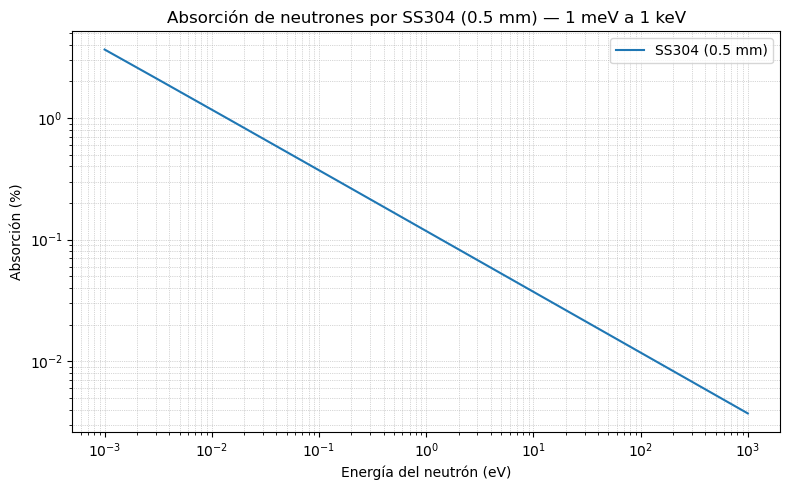

Cálculo completado ✅
Archivo CSV generado: absorcion_SS304_0.5mm.csv


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================================
# Parámetros físicos y composición típica del acero inoxidable SS304
# ==========================================================
# Fracciones másicas típicas (puedes ajustar si conoces valores exactos)
composicion = {
    'Fe': 0.70,
    'Cr': 0.18,
    'Ni': 0.085
}

# Masas atómicas (g/mol)
A = {'Fe': 55.845, 'Cr': 51.996, 'Ni': 58.693}

# Secciones eficaces térmicas (σ a 0.0253 eV) en barns (1 barn = 1e-24 cm²)
# Fuente: tablas ENDF/JEFF (valores representativos)
sigma_thermal_b = {'Fe': 2.0, 'Cr': 0.5, 'Ni': 3.0}

# ==========================================================
# Constantes físicas
# ==========================================================
NA = 6.02214076e23        # Número de Avogadro (átomos/mol)
density = 7.9             # g/cm³ (densidad típica del SS304)
thickness_cm = 0.05       # 0.5 mm = 0.05 cm
barn_to_cm2 = 1e-24       # Conversión barn -> cm²
E0 = 0.0253               # eV, energía de referencia (neutrones térmicos)

# ==========================================================
# Cálculo de densidad atómica por elemento
# ==========================================================
number_density = {}
for el, frac in composicion.items():
    number_density[el] = (frac * density / A[el]) * NA  # átomos/cm³

# ==========================================================
# Energías del rango 1 meV - 1 keV (logarítmicamente espaciadas)
# ==========================================================
energias = np.logspace(-3, 3, 400)  # eV

# ==========================================================
# Función de sección eficaz dependiente de energía (aproximación 1/v)
# σ(E) = σ_0 * sqrt(E0 / E)
# ==========================================================
def sigma_1_over_v(sigma0_b, E):
    return sigma0_b * np.sqrt(E0 / E)

# ==========================================================
# Cálculo de la sección eficaz macroscópica Σ_a(E)
# Σ_a = Σ N_i * σ_i(E)
# ==========================================================
Sigma_a = np.zeros_like(energias)

for el in composicion.keys():
    sigma_E_b = sigma_1_over_v(sigma_thermal_b[el], energias)
    sigma_E_cm2 = sigma_E_b * barn_to_cm2
    Sigma_a += number_density[el] * sigma_E_cm2  # cm⁻¹

# ==========================================================
# Transmisión y absorción
# T(E) = exp(-Σ_a * x)
# Absorción = (1 - T) * 100 [%]
# ==========================================================
transmision = np.exp(-Sigma_a * thickness_cm)
absorcion = (1 - transmision) * 100

# ==========================================================
# Gráfica de absorción vs energía
# ==========================================================
plt.figure(figsize=(8,5))
plt.loglog(energias, absorcion, label='SS304 (0.5 mm)')
plt.xlabel('Energía del neutrón (eV)')
plt.ylabel('Absorción (%)')
plt.title('Absorción de neutrones por SS304 (0.5 mm) — 1 meV a 1 keV')
plt.grid(True, which='both', ls=':', lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================================
# Guardar los datos a CSV (opcional)
# ==========================================================
df = pd.DataFrame({
    'Energia_eV': energias,
    'Sigma_a_cm-1': Sigma_a,
    'Transmision': transmision,
    'Absorcion_%': absorcion
})
df.to_csv('absorcion_SS304_0.5mm.csv', index=False)

print("Cálculo completado ✅")
print("Archivo CSV generado: absorcion_SS304_0.5mm.csv")


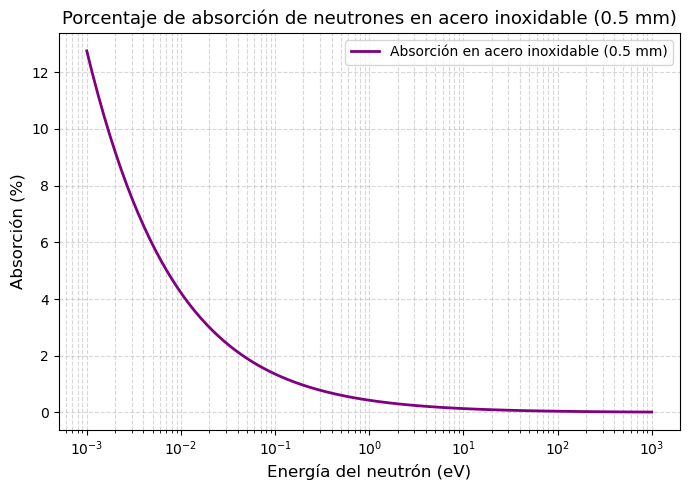

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# === Datos de ejemplo (puedes reemplazarlos con los reales) ===
# Energía del neutrón (en eV)
energia = np.logspace(-3, 3, 100)  # de 1 meV (1e-3 eV) a 1 keV (1e3 eV)

# Sección eficaz de absorción del acero inoxidable (cm²/átomo)
# Datos ficticios, solo como ejemplo de tendencia
sigma_abs = 1e-24 * (1 / np.sqrt(energia))  # decrece con la energía

# Propiedades del acero inoxidable
densidad = 8.0  # g/cm³
espesor = 0.05  # cm (0.5 mm)
masa_molar = 55.85  # g/mol (aprox. hierro dominante)
N_A = 6.022e23  # átomos/mol

# Cálculo del número de átomos por cm³
n = (densidad * N_A) / masa_molar  # átomos/cm³

# === Cálculo del porcentaje de absorción ===
# P_abs = 1 - exp(-n * sigma_abs * espesor)
P_abs = 1 - np.exp(-n * sigma_abs * espesor)
P_abs *= 100  # convertir a %

# === Gráfica ===
plt.figure(figsize=(7, 5))
plt.plot(energia, P_abs, color='purple', linewidth=2, label='Absorción en acero inoxidable (0.5 mm)')

# Escala logarítmica solo en el eje X
plt.xscale('log')

# Etiquetas y formato
plt.xlabel("Energía del neutrón (eV)", fontsize=12)
plt.ylabel("Absorción (%)", fontsize=12)
plt.title("Porcentaje de absorción de neutrones en acero inoxidable (0.5 mm)", fontsize=13)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
import numpy as np
import pandas as pd

# ---------- Parámetros (ajusta si hace falta) ----------
composicion = {'Fe': 0.70, 'Cr': 0.18, 'Ni': 0.085}  # fracción másica
A = {'Fe': 55.845, 'Cr': 51.996, 'Ni': 58.693}      # g/mol
sigma_thermal_b = {'Fe': 2.0, 'Cr': 0.5, 'Ni': 3.0}  # barns (a 0.0253 eV) - revisa estos valores
density = 7.9          # g/cm3 (SS304 típico)
thickness_mm = 0.5     # mm (asegúrate que sea 0.5 y no 5.0...)
thickness_cm = thickness_mm / 10.0  # cm
NA = 6.02214076e23
barn_to_cm2 = 1e-24
E0 = 0.0253  # eV

# ---------- Función 1/v ----------
def sigma_1_over_v(sigma0_b, E):
    return sigma0_b * np.sqrt(E0 / E)

# ---------- Energías y punto de chequeo ----------
energies = np.logspace(-3, -1, 5)  # 1 meV .. 100 meV -> here we sample 1e-3, 1e-2.25, ...1e-1
E_check = 0.001  # 1 meV (eV) - punto principal de interés
# (también calcularemos en 0.0253 eV para comparar con sigma_thermal_b)

# ---------- Cálculo densidad atómica (átomos/cm3) ----------
number_density = {}
for el, frac in composicion.items():
    n = (frac * density / A[el]) * NA
    number_density[el] = n

# ---------- Imprimir densidades atómicas ----------
print("Densidad atómica (átomos/cm^3) por elemento:")
for el, n in number_density.items():
    print(f"  {el:>3} : {n:.3e}")

print("\nVerificación: suma total átomos/cm^3 = {:.3e}".format(sum(number_density.values())))

# ---------- Calcular contribuciones a Σ_a en E_check (1 meV) y en E0 (0.0253 eV) ----------
Sigma_a_Echeck = 0.0
Sigma_a_E0 = 0.0

print("\nContribuciones por elemento (sigma a 0.0253 eV y a 1 meV):")
for el in composicion.keys():
    sigma0_b = sigma_thermal_b[el]
    sigma_E0_cm2 = sigma0_b * barn_to_cm2
    sigma_Echeck_b = sigma_1_over_v(sigma0_b, E_check)
    sigma_Echeck_cm2 = sigma_Echeck_b * barn_to_cm2

    contrib_E0 = number_density[el] * sigma_E0_cm2
    contrib_Echeck = number_density[el] * sigma_Echeck_cm2

    Sigma_a_E0 += contrib_E0
    Sigma_a_Echeck += contrib_Echeck

    print(f"  {el:>3} | sigma(0.0253 eV) = {sigma0_b:.3f} b -> {sigma_E0_cm2:.3e} cm2")
    print(f"       sigma(1 meV) ≈ {sigma_Echeck_b:.3f} b -> {sigma_Echeck_cm2:.3e} cm2")
    print(f"       contrib Σ_a(0.0253 eV) = {contrib_E0:.3e} cm^-1")
    print(f"       contrib Σ_a(1 meV)    = {contrib_Echeck:.3e} cm^-1\n")

print("Σ_a TOTAL a 0.0253 eV  = {:.3e} cm^-1".format(Sigma_a_E0))
print("Σ_a TOTAL a 1 meV     = {:.3e} cm^-1".format(Sigma_a_Echeck))

# ---------- Transmisión y absorción ----------
for E, Sigma in (("0.0253 eV", Sigma_a_E0), ("1 meV", Sigma_a_Echeck)):
    T = np.exp(-Sigma * thickness_cm)
    absorption = (1.0 - T) * 100.0
    approx_linear = (Sigma * thickness_cm) * 100.0  # aproximación válida para Sigma*x << 1
    print(f"\nPara E = {E}:")
    print(f"  Espesor (cm): {thickness_cm}")
    print(f"  Transmisión T = {T:.6f}")
    print(f"  Absorción exacta = {absorption:.6f} %")
    print(f"  Absorción (aprox. lineal Σ·x) = {approx_linear:.6f} %")

# ---------- Exportar resultados a CSV (opcional) ----------
import pandas as pd
energies_full = np.logspace(-3, -1, 200)
Sigma_a_full = np.zeros_like(energies_full)
for el in composicion.keys():
    sigma_b = sigma_thermal_b[el]
    sigma_b_e = sigma_1_over_v(sigma_b, energies_full) * barn_to_cm2
    Sigma_a_full += number_density[el] * sigma_b_e

trans_full = np.exp(-Sigma_a_full * thickness_cm)
abs_full = (1 - trans_full) * 100.0
df = pd.DataFrame({'E_eV': energies_full, 'Sigma_a_cm-1': Sigma_a_full, 'Abs_%': abs_full})
df.to_csv('debug_absorption_values.csv', index=False)
print("\nCSV 'debug_absorption_values.csv' generado con valores punto a punto.")


Densidad atómica (átomos/cm^3) por elemento:
   Fe : 5.963e+22
   Cr : 1.647e+22
   Ni : 6.890e+21

Verificación: suma total átomos/cm^3 = 8.299e+22

Contribuciones por elemento (sigma a 0.0253 eV y a 1 meV):
   Fe | sigma(0.0253 eV) = 2.000 b -> 2.000e-24 cm2
       sigma(1 meV) ≈ 10.060 b -> 1.006e-23 cm2
       contrib Σ_a(0.0253 eV) = 1.193e-01 cm^-1
       contrib Σ_a(1 meV)    = 5.999e-01 cm^-1

   Cr | sigma(0.0253 eV) = 0.500 b -> 5.000e-25 cm2
       sigma(1 meV) ≈ 2.515 b -> 2.515e-24 cm2
       contrib Σ_a(0.0253 eV) = 8.235e-03 cm^-1
       contrib Σ_a(1 meV)    = 4.142e-02 cm^-1

   Ni | sigma(0.0253 eV) = 3.000 b -> 3.000e-24 cm2
       sigma(1 meV) ≈ 15.090 b -> 1.509e-23 cm2
       contrib Σ_a(0.0253 eV) = 2.067e-02 cm^-1
       contrib Σ_a(1 meV)    = 1.040e-01 cm^-1

Σ_a TOTAL a 0.0253 eV  = 1.482e-01 cm^-1
Σ_a TOTAL a 1 meV     = 7.453e-01 cm^-1

Para E = 0.0253 eV:
  Espesor (cm): 0.05
  Transmisión T = 0.992619
  Absorción exacta = 0.738121 %
  Absorción (aprox. li

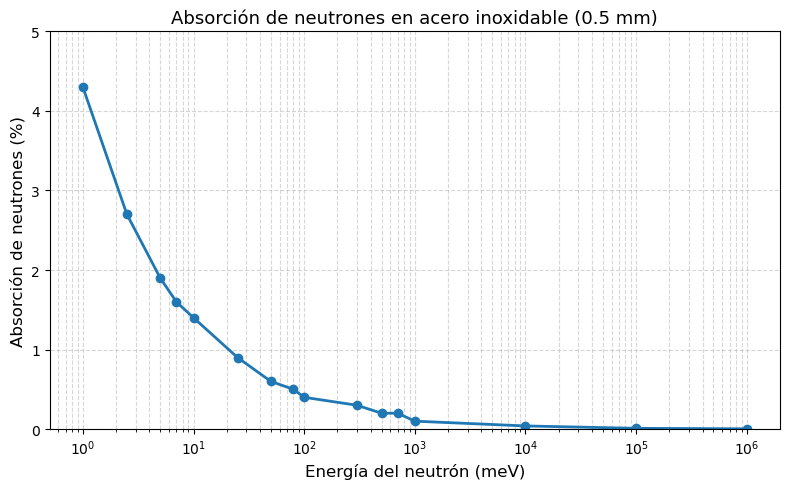

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# === Energía del neutrón (en meV) ===
energia_meV = np.array([
    1, 2.5, 5, 7, 10, 25, 50, 80, 100,
    300, 500, 700, 1000, 10000, 100000, 1000000
])

# === Porcentaje de absorción del acero inoxidable (ejemplo de datos) ===
# Estos valores son ilustrativos; reemplázalos por los calculados a partir de σ(E)
absorcion = np.array([
    4.3, 2.7, 1.9, 1.6, 1.4, 0.9, 0.6, 0.5, 0.4,
    0.3, 0.2, 0.2, 0.1, 0.04, 0.01, 0.004
])

# === Gráfica ===
plt.figure(figsize=(8, 5))
plt.plot(energia_meV, absorcion, marker='o', linestyle='-', linewidth=2, markersize=6)

# Escala logarítmica solo en el eje x
plt.xscale('log')

# Etiquetas
plt.xlabel('Energía del neutrón (meV)', fontsize=12)
plt.ylabel('Absorción de neutrones (%)', fontsize=12)
plt.title('Absorción de neutrones en acero inoxidable (0.5 mm)', fontsize=13)

# Cuadrícula
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Rango de ejes
plt.ylim(0, 5)

# Mostrar gráfica
plt.tight_layout()
plt.show()


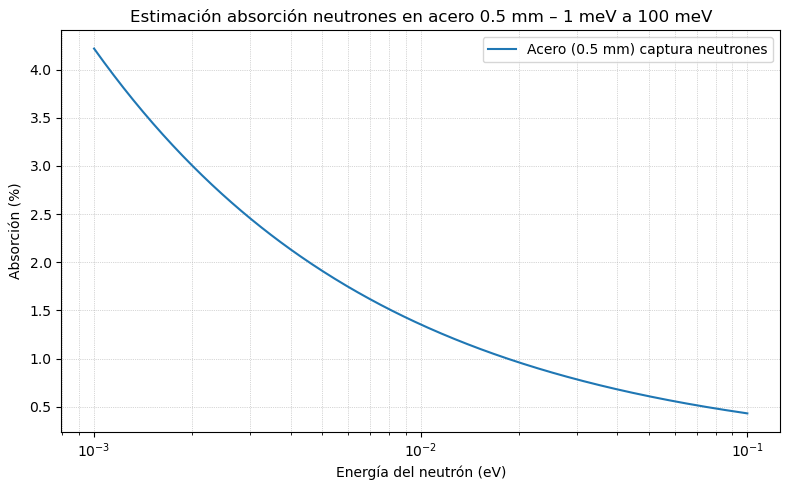

Archivo CSV generado: 'absorcion_acero_0.5mm_1meV-100meV.csv'


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parámetros del acero (aproximación)
composicion = {'Fe': 0.70, 'Cr': 0.18, 'Ni': 0.085}
A = {'Fe': 55.845, 'Cr': 51.996, 'Ni': 58.693}

# Valores térmicos de σ de captura más precisos
# Para Fe-56: σ0 ≈ 2.39 barns según estudio reciente. :contentReference[oaicite:1]{index=1}
# Para Cr y Ni usamos estimados similares a antes (puedes sustituir por valores evaluados)
sigma_thermal_b = {'Fe': 2.39, 'Cr': 0.5, 'Ni': 3.0}  # barns a 0.0253 eV

# Constantes físicas
NA = 6.02214076e23        # núm. Avogadro
density = 7.9             # g/cm³
thickness_mm = 0.5        # mm
thickness_cm = thickness_mm / 10.0
barn_to_cm2 = 1e-24
E0 = 0.0253               # eV referencia

# Calcular densidad atómica
number_density = {}
for el, frac in composicion.items():
    number_density[el] = (frac * density / A[el]) * NA

# Energías entre 1 meV y 100 meV
energies = np.logspace(-3, -1, 400)  # eV (1e-3 eV = 1 meV, up to 1e-1 eV = 100 meV)

# Función σ(E) ~ σ0 * sqrt(E0/E)
def sigma_1_over_v(sigma0_b, E):
    return sigma0_b * np.sqrt(E0 / E)

# Calcular Σ_a(E)
Sigma_a = np.zeros_like(energies)
for el in composicion.keys():
    sigma_E_b = sigma_1_over_v(sigma_thermal_b[el], energies)
    sigma_E_cm2 = sigma_E_b * barn_to_cm2
    Sigma_a += number_density[el] * sigma_E_cm2

# Calcular transmisión y absorción
transmission = np.exp(-Sigma_a * thickness_cm)
absorption_percent = (1.0 - transmission) * 100.0

# Guardar resultados en CSV
df = pd.DataFrame({
    'Energy_eV': energies,
    'Sigma_a_cm-1': Sigma_a,
    'Transmission': transmission,
    'Absorption_%': absorption_percent
})
df.to_csv('absorcion_acero_0.5mm_1meV-100meV.csv', index=False)

# Graficar absorción vs energía (eje X log)
plt.figure(figsize=(8,5))
plt.plot(energies, absorption_percent, label='Acero (0.5 mm) captura neutrones')
plt.xscale('log')
plt.xlabel('Energía del neutrón (eV)')
plt.ylabel('Absorción (%)')
plt.title('Estimación absorción neutrones en acero 0.5 mm – 1 meV a 100 meV')
plt.grid(True, which='both', ls=':', lw=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print("Archivo CSV generado: 'absorcion_acero_0.5mm_1meV-100meV.csv'")


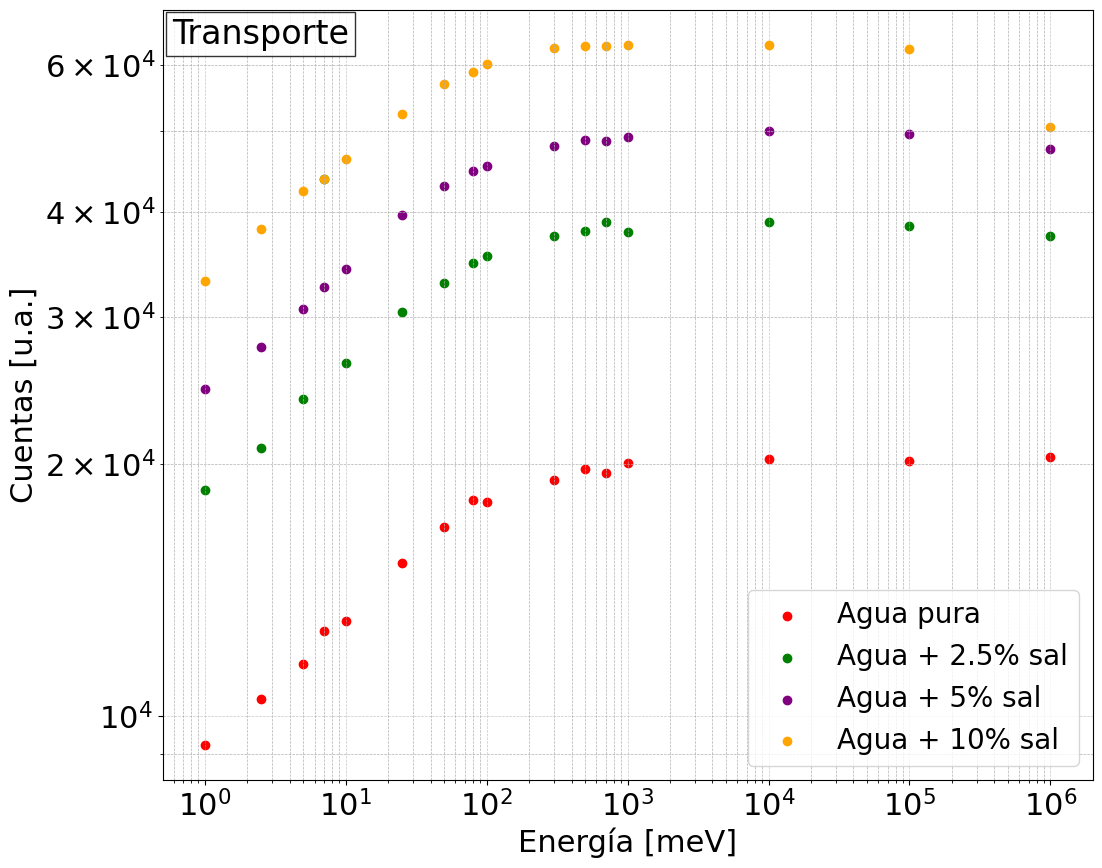

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
energia = np.array([1, 2.5, 5, 7, 10, 25, 50, 80, 100, 300,500, 700, 1000, 10000, 100000, 1000000])

agua_pura = np.array([9239, 10476, 11547, 12646, 12993, 15241, 16834, 18136, 18020, 19134, 19752, 19521, 20068, 20308, 20195, 20419])

sal_2_5 = np.array([18606, 20932, 23944, 43871, 26383, 30410, 32950, 34769, 35422, 37443, 37967, 38896, 37897, 38987, 38481, 37487])

sal_5 = np.array([24595, 27592, 30624, 32567, 34193, 39671, 43011, 44835, 45403, 47935, 48811, 48664, 49253, 50073, 49569, 47633])

sal_10 = np.array([33116, 38172, 42405, 43871, 46320, 52381, 56890, 58791, 60159, 62777, 63282, 63270, 63422, 63355, 62638, 50524])

# Crear figura
plt.figure(figsize=(12, 10))

# Graficar puntos
plt.scatter(energia, agua_pura, color='red', label='Agua pura')
plt.scatter(energia, sal_2_5, color='green', label='Agua + 2.5% sal')
plt.scatter(energia, sal_5, color='purple', label='Agua + 5% sal')
plt.scatter(energia, sal_10, color='orange', label='Agua + 10% sal')

# Escalas logarítmicas
plt.xscale('log')
plt.yscale('log')

# Etiquetas y título
plt.xlabel('Energía [meV]', fontsize=22)
plt.ylabel('Cuentas [u.a.]', fontsize=22)
plt.title('')
plt.legend(fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.grid(True, which="both", ls="--", linewidth=0.5)
#plt.ticklabel_format(useOffset=False, axis='x')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=22)  # Tics mayores
plt.text(
    0.01, 0.99,
    #r"$^{16}\mathrm{O} + n \rightarrow\ ^{17}\mathrm{O}^{*} \rightarrow\ ^{17}\mathrm{O} + \gamma$",
    f"Transporte",
    transform=plt.gca().transAxes,
    fontsize=24,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
# Guardar figura
plt.savefig('Transportation_vs_energia.png', dpi=300)
plt.savefig('Transportation_vs_energia.pdf')

# Mostrar gráfico
plt.show()


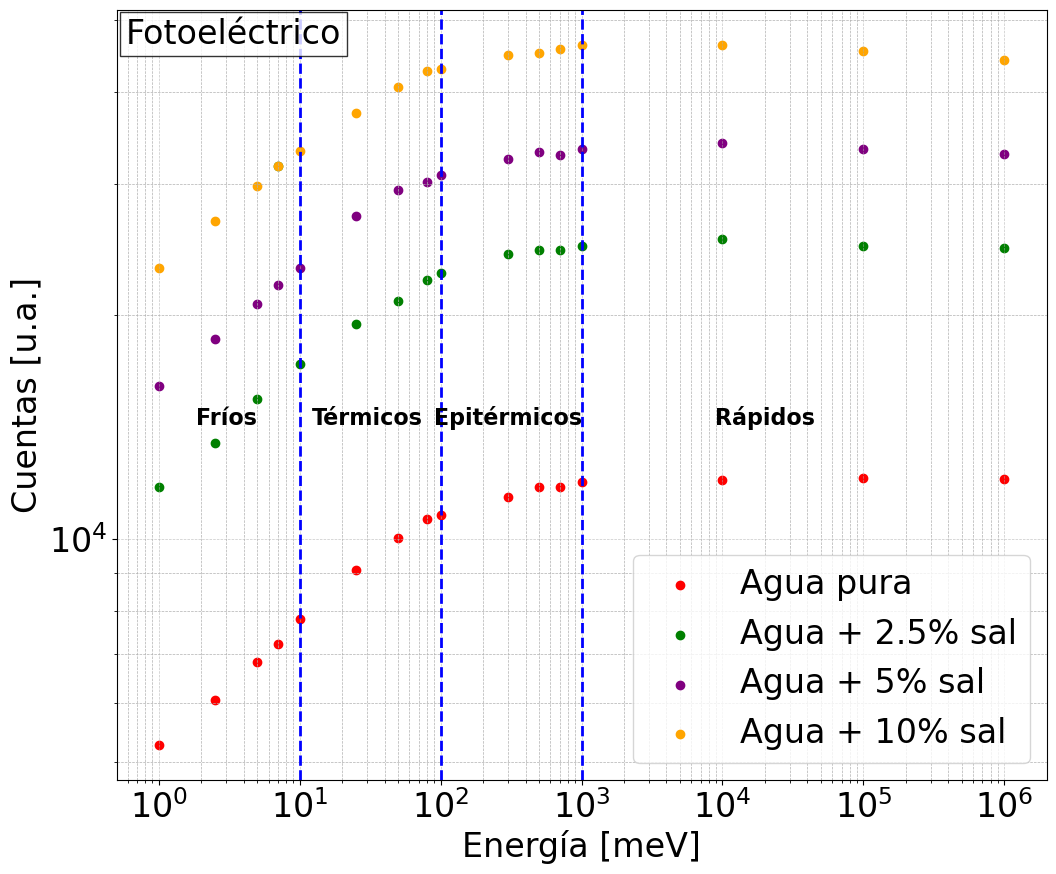

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
energia = np.array([1, 2.5, 5, 7, 10, 25, 50, 80, 100, 300,500, 700, 1000, 10000, 100000, 1000000])

agua_pura = np.array([5273, 6056, 6827, 7206, 7790, 9072, 10028, 10616, 10755, 11371, 11729, 11742, 11902, 11997, 12081, 12028])

sal_2_5 = np.array([11752, 13441, 15405, 31795, 17179, 19467, 20882, 22318, 22784, 24200, 24506, 24512, 24756, 25312, 24818, 24644])

sal_5 = np.array([16070, 18591, 20682, 21974, 23164, 27198, 29497, 30187, 30844, 32424, 33223, 32895, 33529, 34096, 33527, 32959])

sal_10 = np.array([23151, 26767, 29888, 31795, 33312, 37478, 40613, 42607, 42964, 44765, 45088, 45697, 46168, 46246, 45350, 44172])

# Crear figura
plt.figure(figsize=(12, 10))

# Graficar puntos
plt.scatter(energia, agua_pura, color='red', label='Agua pura')
plt.scatter(energia, sal_2_5, color='green', label='Agua + 2.5% sal')
plt.scatter(energia, sal_5, color='purple', label='Agua + 5% sal')
plt.scatter(energia, sal_10, color='orange', label='Agua + 10% sal')

# Líneas verticales que delimitan las regiones de energía
plt.axvline(x=10, color='blue', linestyle='--', linewidth=2)
plt.axvline(x=100, color='blue', linestyle='--', linewidth=2)
plt.axvline(x=1000, color='blue', linestyle='--', linewidth=2)

# Agregar etiquetas para cada región en la parte superior
plt.text(3, 14000, 'Fríos', fontsize=16, ha='center', va='bottom', fontweight='bold')
plt.text(30, 14000, 'Térmicos', fontsize=16, ha='center', va='bottom', fontweight='bold')
plt.text(300, 14000, 'Epitérmicos', fontsize=16, ha='center', va='bottom', fontweight='bold')
plt.text(20000, 14000, 'Rápidos', fontsize=16, ha='center', va='bottom', fontweight='bold')



# Escalas logarítmicas
plt.xscale('log')
plt.yscale('log')

# Etiquetas y título
plt.xlabel('Energía [meV]', fontsize=24)
plt.ylabel('Cuentas [u.a.]', fontsize=24)
plt.title('')
plt.legend(fontsize=24)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.grid(True, which="both", ls="--", linewidth=0.5)
#plt.ticklabel_format(useOffset=False, axis='x')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=24)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=24)  # Tics mayores
plt.text(
    0.01, 0.99,
    #r"$^{16}\mathrm{O} + n \rightarrow\ ^{17}\mathrm{O}^{*} \rightarrow\ ^{17}\mathrm{O} + \gamma$",
    f"Fotoeléctrico",
    transform=plt.gca().transAxes,
    fontsize=24,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

# Guardar figura
plt.savefig('Fotoelectrico_vs_energia.png', dpi=300)
plt.savefig('Fotoelectrico_vs_energia.pdf')

# Mostrar gráfico
plt.show()


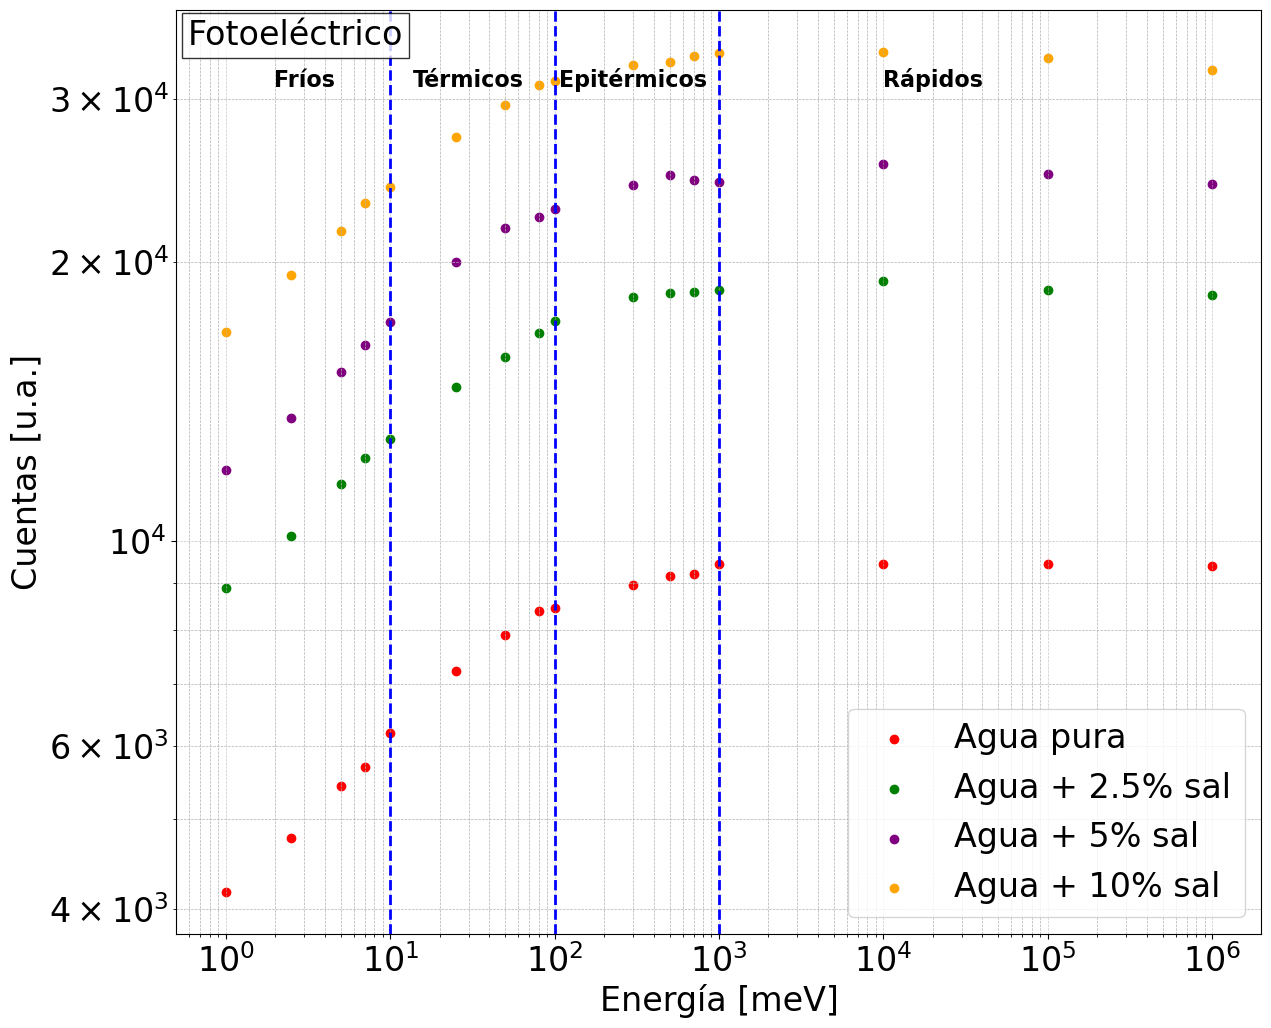

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
energia = np.array([1, 2.5, 5, 7, 10, 25, 50, 80, 100, 300,500, 700, 1000, 10000, 100000, 1000000])

agua_pura = np.array([4175, 4776, 5432, 5695, 6203, 7225, 7917, 8387, 8464, 8946, 9170, 9194, 9433, 9429, 9446, 9397])

sal_2_5 = np.array([8884, 10111, 11528, 12271, 12870, 14643, 15809, 16748, 17275, 18332, 18508, 18543, 18645, 19071, 18641, 18430])

sal_5 = np.array([11928, 13573, 15225, 16264, 17218, 20010, 21785, 22391, 22828, 24224, 24799, 24497, 24406, 25491, 24888, 24288])

sal_10 = np.array([16783, 19348, 21626, 23142, 24126, 27303, 29547, 31035, 31405, 32626, 32901, 33351, 33601, 33720, 33220, 32248])

# Crear figura
plt.figure(figsize=(14, 12))

# Graficar puntos
plt.scatter(energia, agua_pura, color='red', label='Agua pura')
plt.scatter(energia, sal_2_5, color='green', label='Agua + 2.5% sal')
plt.scatter(energia, sal_5, color='purple', label='Agua + 5% sal')
plt.scatter(energia, sal_10, color='orange', label='Agua + 10% sal')
# Líneas verticales que delimitan las regiones de energía
plt.axvline(x=10, color='blue', linestyle='--', linewidth=2)
plt.axvline(x=100, color='blue', linestyle='--', linewidth=2)
plt.axvline(x=1000, color='blue', linestyle='--', linewidth=2)

# Agregar etiquetas para cada región en la parte superior
plt.text(3, 30500, 'Fríos', fontsize=16, ha='center', va='bottom', fontweight='bold')
plt.text(30, 30500, 'Térmicos', fontsize=16, ha='center', va='bottom', fontweight='bold')
plt.text(300, 30500, 'Epitérmicos', fontsize=16, ha='center', va='bottom', fontweight='bold')
plt.text(20000, 30500, 'Rápidos', fontsize=16, ha='center', va='bottom', fontweight='bold')


# Escalas logarítmicas
plt.xscale('log')
plt.yscale('log')

# Etiquetas y título
plt.xlabel('Energía [meV]', fontsize=24)
plt.ylabel('Cuentas [u.a.]', fontsize=24)
plt.title('')
plt.legend(fontsize=24)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.grid(True, which="both", ls="--", linewidth=0.5)
#plt.ticklabel_format(useOffset=False, axis='x')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=24)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=24)  # Tics mayores
plt.text(
    0.01, 0.99,
    #r"$^{16}\mathrm{O} + n \rightarrow\ ^{17}\mathrm{O}^{*} \rightarrow\ ^{17}\mathrm{O} + \gamma$",
    f"Fotoeléctrico",
    transform=plt.gca().transAxes,
    fontsize=24,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)

# Guardar figura
plt.savefig('Fotoelectrico_vs_energia.png', dpi=300)
plt.savefig('Fotoelectrico_vs_energia.pdf')

# Mostrar gráfico
plt.show()


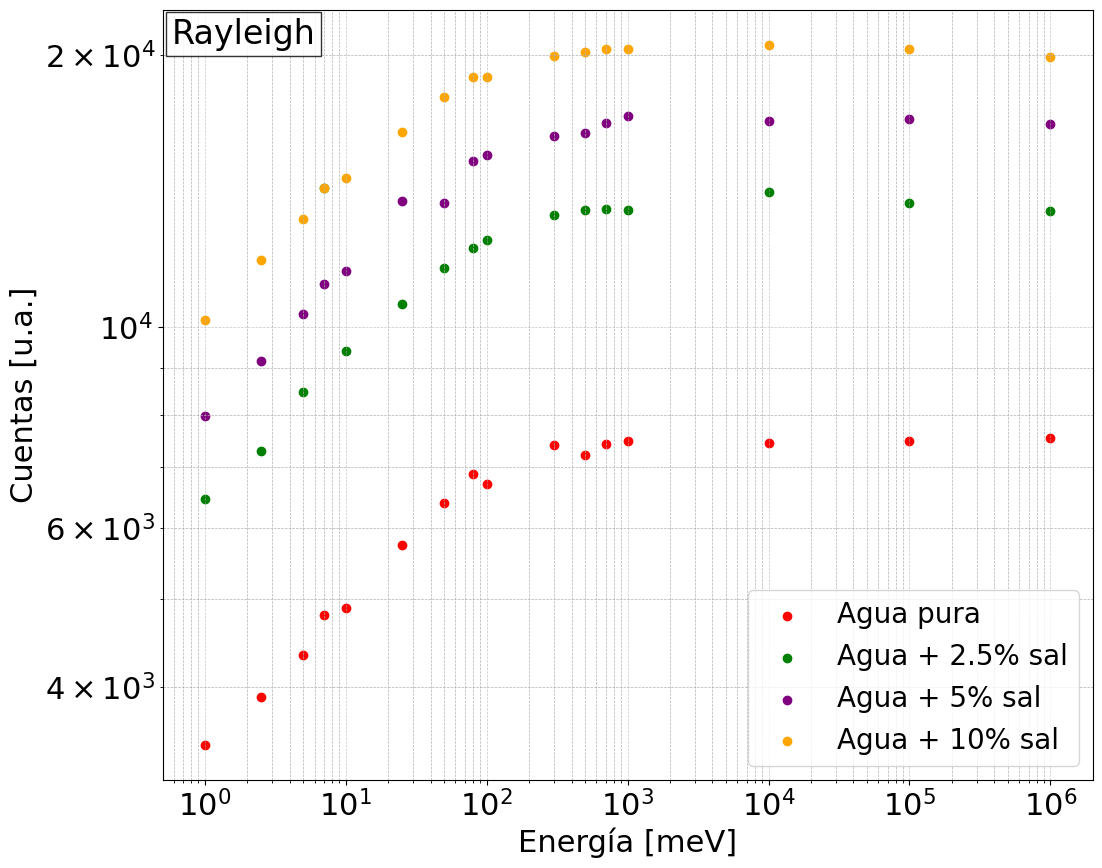

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
energia = np.array([1, 2.5, 5, 7, 10, 25, 50, 80, 100, 300,500, 700, 1000, 10000, 100000, 1000000])

agua_pura = np.array([3453, 3899, 4338, 4810, 4893, 5742, 6396, 6873, 6709, 7411, 7223, 7425, 7483, 7440, 7479, 7538])

sal_2_5 = np.array([6450, 7288, 8467, 14238, 9418, 10605, 11620, 12242, 12476, 13313, 13468, 13522, 13486, 14121, 13715, 13435])

sal_5 = np.array([7976, 9176, 10346, 11161, 11530, 13793, 13710, 15263, 15515, 16285, 16396, 16831, 17104, 16906, 16966, 16782])

sal_10 = np.array([10181, 11868, 13163, 14238, 14605, 16445, 17969, 18914, 18881, 19916, 20151, 20305, 20315, 20520, 20272, 19864])

# Crear figura
plt.figure(figsize=(12, 10))

# Graficar puntos
plt.scatter(energia, agua_pura, color='red', label='Agua pura')
plt.scatter(energia, sal_2_5, color='green', label='Agua + 2.5% sal')
plt.scatter(energia, sal_5, color='purple', label='Agua + 5% sal')
plt.scatter(energia, sal_10, color='orange', label='Agua + 10% sal')

# Escalas logarítmicas
plt.xscale('log')
plt.yscale('log')

# Etiquetas y título
plt.xlabel('Energía [meV]', fontsize=22)
plt.ylabel('Cuentas [u.a.]', fontsize=22)
plt.title('')
plt.legend(fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.grid(True, which="both", ls="--", linewidth=0.5)
#plt.ticklabel_format(useOffset=False, axis='x')
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tick_params(axis='x', which='both', labelsize=22)  # Tics mayores
plt.tick_params(axis='y', which='both', labelsize=22)  # Tics mayores
plt.text(
    0.01, 0.99,
    #r"$^{16}\mathrm{O} + n \rightarrow\ ^{17}\mathrm{O}^{*} \rightarrow\ ^{17}\mathrm{O} + \gamma$",
    f"Rayleigh",
    transform=plt.gca().transAxes,
    fontsize=24,
    verticalalignment='top',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
# Guardar figura
plt.savefig('Rayleigh_vs_energia.png', dpi=300)
plt.savefig('Rayleigh_vs_energia.pdf')

# Mostrar gráfico
plt.show()


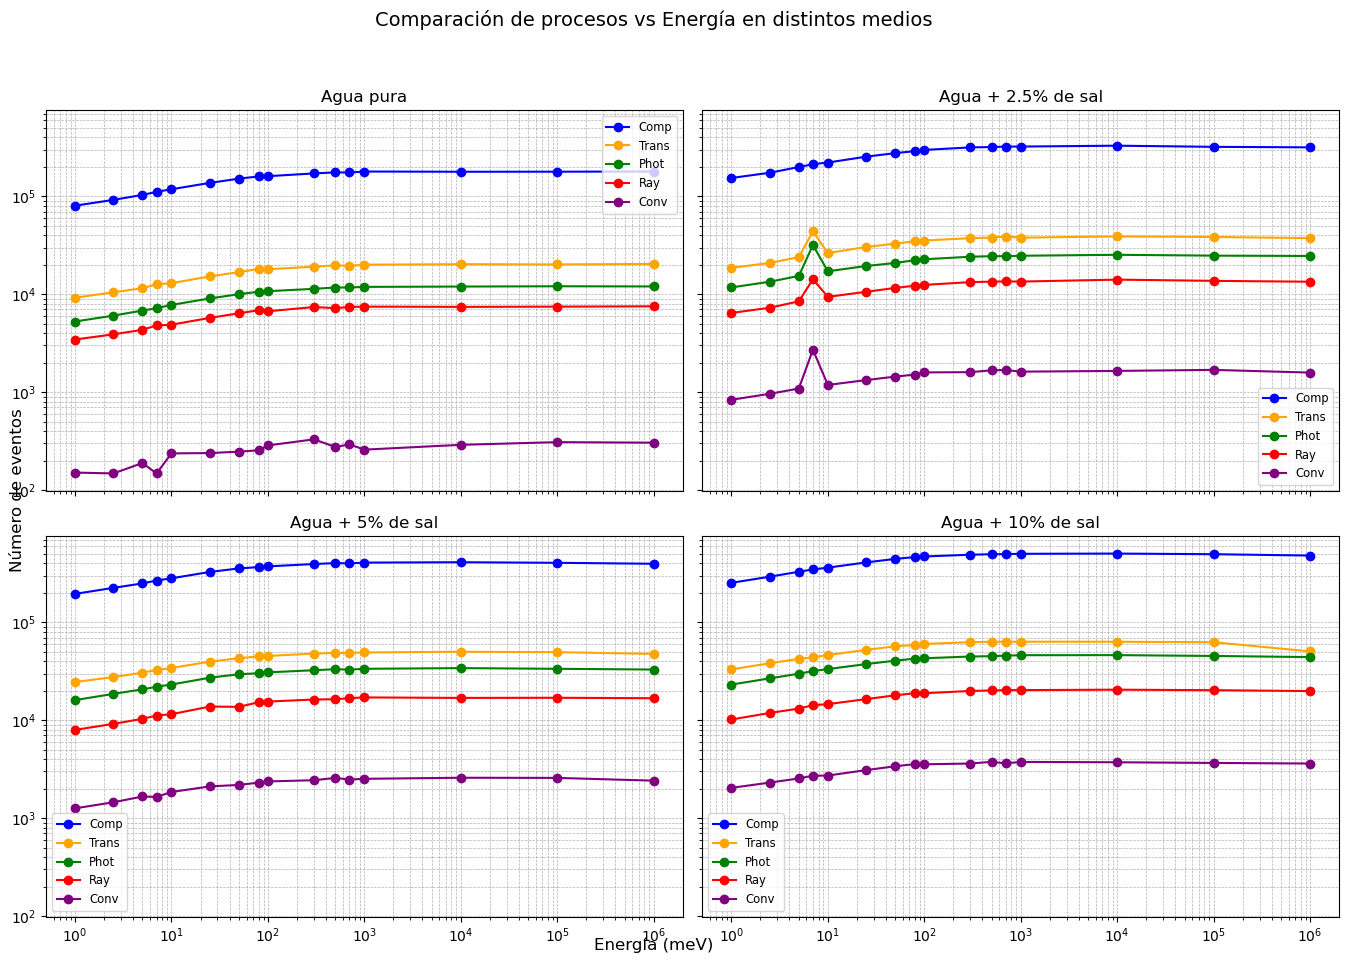

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# Energías (meV)
energia = np.array([
    1, 2.5, 5, 7, 10, 25, 50, 80, 100, 300,
    500, 700, 1000, 10000, 100000, 1000000
])

# Datos para cada proceso y condición
agua_pura = {
    "Comp": [80358, 92144, 103531, 111216, 118314, 137332, 151733, 159938, 160846, 171588, 175972, 175489, 179493, 178487, 178748, 179525],
    "Trans": [9239, 10476, 11547, 12646, 12993, 15241, 16834, 18136, 18020, 19134, 19752, 19521, 20068, 20308, 20195, 20419],
    "Phot": [5273, 6056, 6827, 7206, 7790, 9072, 10028, 10616, 10755, 11371, 11729, 11742, 11902, 11997, 12081, 12028],
    "Ray": [3453, 3899, 4338, 4810, 4893, 5742, 6396, 6873, 6709, 7411, 7223, 7425, 7483, 7440, 7479, 7538],
    "Conv": [151, 148, 189, 148, 237, 239, 247, 255, 286, 330, 276, 293, 259, 290, 309, 305]
}

sal_2_5 = {
    "Comp": [154185, 174344, 199562, 213234, 221597, 254617, 276588, 289948, 298448, 316361, 319202, 322727, 322842, 329490, 320754, 316740],
    "Trans": [18606, 20932, 23944, 43871, 26383, 30410, 32950, 34769, 35422, 37443, 37967, 38896, 37897, 38987, 38481, 37487],
    "Phot": [11752, 13441, 15405, 31795, 17179, 19467, 20882, 22318, 22784, 24200, 24506, 24512, 24756, 25312, 24818, 24644],
    "Ray": [6450, 7288, 8467, 14238, 9418, 10605, 11620, 12242, 12476, 13313, 13468, 13522, 13486, 14121, 13715, 13435],
    "Conv": [837, 963, 1090, 2714, 1186, 1330, 1443, 1513, 1592, 1602, 1674, 1684, 1621, 1650, 1690, 1586]
}

sal_5 = {
    "Comp": [195312, 224969, 249806, 267236, 281746, 327185, 355488, 366268, 372898, 393964, 402929, 399879, 407504, 411299, 405550, 396396],
    "Trans": [24595, 27592, 30624, 32567, 34193, 39671, 43011, 44835, 45403, 47935, 48811, 48664, 49253, 50073, 49569, 47633],
    "Phot": [16070, 18591, 20682, 21974, 23164, 27198, 29497, 30187, 30844, 32424, 33223, 32895, 33529, 34096, 33527, 32959],
    "Ray": [7976, 9176, 10346, 11161, 11530, 13793, 13710, 15263, 15515, 16285, 16396, 16831, 17104, 16906, 16966, 16782],
    "Conv": [1260, 1452, 1664, 1647, 1851, 2110, 2184, 2306, 2371, 2440, 2574, 2480, 2523, 2586, 2577, 2415]
}

sal_10 = {
    "Comp": [253309, 292612, 328785, 346624, 361959, 409492, 444663, 464414, 470626, 490699, 495988, 497668, 501148, 503909, 496482, 481129],
    "Trans": [33116, 38172, 42405, 43871, 46320, 52381, 56890, 58791, 60159, 62777, 63282, 63270, 63422, 63355, 62638, 50524],
    "Phot": [23151, 26767, 29888, 31795, 33312, 37478, 40613, 42607, 42964, 44765, 45088, 45697, 46168, 46246, 45350, 44172],
    "Ray": [10181, 11868, 13163, 14238, 14605, 16445, 17969, 18914, 18881, 19916, 20151, 20305, 20315, 20520, 20272, 19864],
    "Conv": [2039, 2308, 2544, 2714, 2723, 3097, 3390, 3566, 3549, 3613, 3760, 3628, 3753, 3722, 3664, 3614]
}

# Colores para cada proceso
colors = {
    "Comp": "blue",
    "Trans": "orange",
    "Phot": "green",
    "Ray": "red",
    "Conv": "purple"
}

# Crear figura
fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

# Función para graficar cada conjunto
def plot_set(ax, data, title):
    for proceso, color in colors.items():
        ax.plot(energia, data[proceso], label=proceso, color=color, marker='o')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(title)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.legend(fontsize='small')

# Graficar en cada subgráfico
plot_set(axs[0, 0], agua_pura, 'Agua pura')
plot_set(axs[0, 1], sal_2_5, 'Agua + 2.5% de sal')
plot_set(axs[1, 0], sal_5, 'Agua + 5% de sal')
plot_set(axs[1, 1], sal_10, 'Agua + 10% de sal')

# Etiquetas globales
fig.text(0.5, 0.04, 'Energía (meV)', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Número de eventos', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Comparación de procesos vs Energía en distintos medios', fontsize=14)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.savefig("procesos_vs_energia_matriz.png", dpi=300)
plt.show()
